In [1]:
import sys, glob, os, yaml, sparse, tracemalloc, vcf, shutil
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scipy.stats as st
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler

from dna_features_viewer import BiopythonTranslator, GraphicFeature, GraphicRecord
from dna_features_viewer.biotools import annotate_biopython_record
import itertools, difflib

import warnings
warnings.filterwarnings("ignore")

who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_resistance_variants_all.csv")
who_variants_clean = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")
lineages = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineages.csv")

# sys.path.append("utils")
# from model_utils import *
# from data_utils import *
# from dataloader import MtbGeneDataset
import Bio.SeqUtils
from Bio import Seq, SeqIO

# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import backend as K
# from tensorflow.keras.optimizers import Adam
# print(f"Tensorflow version: {tf.__version__}")

df_mxf = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/data_for_model.csv")
df_rif = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/data_for_model.csv")

lineages = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineages.csv")#.rename(columns={"Coll2014": "Lineage"})

df_mxf_val = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/validation_data_for_model.csv")
df_rif_val = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/validation_data_for_model.csv")

coll_2014 = pd.read_csv("/home/sak0914/who-analysis/data/coll2014_SNP_scheme.tsv", sep="\t")
freschi_2020 = pd.read_csv("/home/sak0914/who-analysis/data/freschi2020_SNP_scheme.tsv", sep="\t")

results_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"
solo_results = pd.read_excel("/home/sak0914/who-analysis/data/SOLO primary_STATA_ver18Feb2023.xlsx", sheet_name="Sheet1")

h37Rv_genes = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/mycobrowser_h37rv_genes_v4.csv")

In [4]:
np.mean(np.log2(df_rif["RIF_midpoint"])), np.mean(df_rif["RIF_midpoint"])

(-0.9317225234636801, 6.330409324723651)

In [3]:
np.mean(np.log2(df_mxf["MXF_midpoint"]))

-3.063541858435793

In [5]:
a[3:3+4] = [10, 11, 12, 13]

In [9]:
PATHS_FILE, START, END, SENSE, OUT_FILE = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/combined_paths_for_aln.txt", 2606707, 2608795, "NEG", "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/fastas/stp.fasta"
ADDITIONAL_ISOLATES_FILE = None

In [50]:
START = 226571
END = 230462

In [51]:
SENSE = SENSE.upper()
assert SENSE in ["POS", "NEG"]

if not os.path.isfile(PATHS_FILE):
    raise ValueError(f"{PATHS_FILE} is not a file!")
    
# PATHS_FILE should be a text file of paths
if PATHS_FILE[-4:] != ".txt":
    raise ValueError(f"{PATHS_FILE} must be a text file!")
    
if ADDITIONAL_ISOLATES_FILE is not None:
    
    if not os.path.isfile(ADDITIONAL_ISOLATES_FILE):
        raise ValueError(f"{ADDITIONAL_ISOLATES_FILE} is not a file!")
    
    # PATHS_FILE should be a text file of paths
    if ADDITIONAL_ISOLATES_FILE[-4:] != ".txt":
        raise ValueError(f"{ADDITIONAL_ISOLATES_FILE} must be a text file!")
    
    add_paths = pd.read_csv(ADDITIONAL_ISOLATES_FILE, sep="\t", header=None)[0].values
    
else:
    add_paths = []

paths = pd.read_csv(PATHS_FILE, sep="\t", header=None)[0].values    
print(f"Making {SENSE} multiple sequence alignment for {len(paths)} sequences and {len(add_paths)} additional sequences")
paths = np.concatenate([paths, add_paths], axis=0)

if ".fasta" not in OUT_FILE:
    OUT_FILE = OUT_FILE.split(".")[0] + ".fasta"
    
if not os.path.isdir(os.path.dirname(OUT_FILE)):
    os.makedirs(os.path.dirname(OUT_FILE))
    
# H37Rv reference strain
h37Rv = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")
genome_len = len(h37Rv)
print(f"Reference genome size: {genome_len}")

# get only the region of interest
h37Rv_region = list(str(h37Rv.seq[START:END]))
print(f"Unaligned region size: {len(h37Rv_region)}")
del h37Rv

    
def reverse_complement(seq):
    
    comp_dict = {'A': 'T', 
                 'C': 'G', 
                 'G': 'C', 
                 'T': 'A', 
                 'N': 'N', 
                 '-': '-'
                }
    
    # this is to turn it into a list where each element is of length 1
    seq = list("".join(seq))
    seq = [comp_dict[base] for base in seq] 
    
    # reverse the sequence and return as a list
    return "".join(seq[::-1])

    
    
def allele_category(record, qualThresh=10, heteroThresh=0.25):
    '''
    Returns "alt" or "ref" if the variant is low-quality or ambiguous. Otherwise this function returns "missing"
    
    Low-quality criteria:
    
        1. FILTER == Del, LowCov
        2. FILTER == Amb and 0.1 < AF < 0.9
        3. IMPRECISE variant (in the INFO field)
        4. SNP quality < 10
        
        
    If FILTER contains Amb and the alternative allele fraction > 0.9, then it is a pure alternative call. 
    If FILTER contains Amb and the alternative allele fraction < 0.1, the it is a pure reference call. 
    '''
    
    # fill in things that might be missing
    if "AF" not in record.INFO.keys():
        af = 0.76
    else:
        af_lst = record.INFO["AF"]
        
        # more than one alternative allele -- heterogeneous alternative allele
        if len(af_lst) > 1:
            return "missing"
        else:
            af = float(af_lst[0])
        
    if record.QUAL is None:
        qual = 11
    else:
        qual = record.QUAL
        
    if "IMPRECISE" in record.INFO.keys():
        return "missing"
    
    # the filter field is an empty list of it is PASS, else the list is non-empty
    # only consider the non-Amb cases here. Amb cases will be later, check the AF too for that
    if len(record.FILTER) > 0 and "Amb" not in record.FILTER:
        return "missing"
    
    # ambiguous reference or alternative alleles. I think these are very rare though
    if "N" in record.REF or "N" in "".join(np.array(record.ALT).astype(str)):
        return "missing"
    
    # check if there are any non alphanumeric characters. This would indicate a heterogeneous alternative allele
    if not "".join(np.array(record.ALT).astype(str)).isalnum():
        return "missing"
        
    # PASS or Amb filters and an alternative allele fraction of less than 0.9 means we have a mixture of REF and ALT
    if "Amb" in record.FILTER or len(record.FILTER) == 0:
        
        # default heteroThresh = 0.25. So alternative AF > 0.75 or AF < 0.25 to be a pure alternative call or reference call, respectively
        if heteroThresh <= af <= (1-heteroThresh):
            return "missing"
        elif af < heteroThresh:
            return "ref"
        elif af > (1-heteroThresh):
            return "alt"
        
    # low SNP quality or multiple bad FILTER tags. i.e. if the field is Del;Amb, it will be ['Del', 'Amb'] in pyVCF. The length of this will be >= 2
    if qual < qualThresh or len(record.FILTER) > 1:
        return "missing"
        
    # if nothing has been returned, then the variant is high quality (there are no REF = ALT records in the input VCF files, so return the alternative variant)
    # the reference variant only gets returned above if FILTER == Amb and AF < 0.25
    return "alt"

Making NEG multiple sequence alignment for 8569 sequences and 0 additional sequences
Reference genome size: 4411532
Unaligned region size: 3891


In [52]:
START, END

(226571, 230462)

In [33]:
2608795-2606786

2009

In [32]:
2606786+3169

2609955

In [34]:
a

[1, 2, 3, 10, 11, 12, 13, 8, 9, 10]

In [39]:
a[8:8+10] = ['A']*10

In [40]:
a

[1, 2, 3, 10, 11, 12, 13, 8, 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A']

In [53]:
seq = introduce_snps_indels_single_seq("/n/scratch3/users/s/sak0914/annotated_VCF/ERR4831152.eff.vcf",
                                 h37Rv_region,
                                 START,
                                 END
                                )

Record(CHROM=NC_000962.3, POS=227098, REF=T, ALT=[C])
Record(CHROM=NC_000962.3, POS=229871, REF=GACGGTCCGAGTCGACGGATGCGACCTGCGGGAGTTCGATGTCGACGGCTATCGCAACCGGCTCGGCATCGTGACGCAGGAGCAGTACGTCTTCGCCGGGACGGTCCGCGATGCCATCGCATACGGACGGCCCGATGCCACCGATGCCCAGGTCGAACGGGCTGCGCGGGAGGTCGGTGCCCATCCGATGATCACCGCACTCGACAACGGGTACCTGCATCAGGTCACCGCGGGTGGGCGCAATCTGTCCGCCGGTCAGCTGCAGTTGCTCGCATTGGCCAGGGCGCGTCTGGTTGACCCCGACATTCTGCTGCTGGATGAGGCCACCGTGGCCCTGGATCCTGCCACCGAGGCCGTGGTGCAGCGGGCCACCCTCACCCTGGCAGCCCGTCGGACGACCTTGATCGTGGCTCACGGGCTAGCCATCGCCGAACACGCCGACCGCATTGTCGTGCTCGAGCACGGCACCGTTGTCGAGGACGGCGCCCACACCGAACTTCTCGCTGCTGGGGGCCACTATTCGCGGCTGTGGGCGGCCCATACTCGACTGTGTTCGCCGGAAATCACTCAGCTTCAATGTATTGACGCATAGACGTCACCAAGCCACCGAATGGGTGGCGAGTTGACCGGGCGCCGGATCCCGACGGTTGTGGTTGATCTGCCGAATCAACGGCTTCTGGCCACGAACATGTGTCCGCGACTGGCGTCTGCGATACCAACCCAATCGGTTACTATAGAAACTGTTCCCGCCGACAACTAACTCCCTTGTTCGCGTGGAGGGGTTCTCGGGTCCGGTCAGCGAGGTCCGGAGCGGGGCGGAAATTTCATTGAACAGCCGTAGAAGTTCAGCCAGGACCGGAACGGATCCAGCGGCAAGCATGCCTTCAGGAGCCATGTTGTCGAA

In [13]:
len(h37Rv_region)

2088

In [47]:
len(seq)

2088

In [49]:
"".join(seq)

'TCAGGCAGGCCATAGTCGACACCATGTGGCTCCCGGCATATGACTAACCGCGCACTCGACGGTCATCGCTGTAGGCAGC--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
new_seq[idx:idx+len(ref_allele)]

In [24]:
a[3:3+1] = 

[10]

In [44]:
def introduce_snps_indels_single_seq(fName, h37Rv_region, START, END):
    
    new_seq = h37Rv_region.copy()

    vcf_file = vcf.Reader(filename=fName)

    # start is 0-indexed (exclusive) and end is 1-indexed (inclusive)
    for record in vcf_file:
        
        # get only the region of interest
        if record.POS > START and record.POS <= END:

            print(record)

            # get the allele type: ref, alt, or missing
            single_allele_type = allele_category(record)

            # convert alternative allele from list to string
            alt_allele = "".join(np.array(record.ALT).astype(str))

            # the index to replace -- this is 0-indexed, consistent with Python
            idx = record.POS - (START + 1)

            # no length change -- SNP or MNP. Python will replace all elements if the original and new are the same length
            if len(record.REF) == len(alt_allele):

                if single_allele_type == "alt":
                    new_seq[idx:idx+len(record.REF)] = alt_allele
                elif single_allele_type == "missing":
                    new_seq[idx:idx+len(record.REF)] = ["N"]*len(alt_allele)
                # the only other option is reference, so don't do anything
                else:
                    continue

            # indels
            else:

                # insertion
                if len(alt_allele) > len(record.REF):

                    if len(record.REF) == 1:

                        # simply replace the nucleotide at the reference index with the alternative nucleotides
                        # also add the number of gap characters needed (len(ALT) - len(REF), where len(REF) == 1) to insertion_dict at the appropriate index
                        # only consider high-quality insertions and deletions. Leave the others as reference
                        if single_allele_type == "alt":

                            new_seq[idx] = alt_allele
                            insertion_dict[idx] = np.max([insertion_dict[idx], (len(alt_allele) - 1)])
                        
                        # don't do anything if reference or missing. Don't consider missing indels because they often introduce huge regions of N
                        else:
                            continue

                    # complex variant -- don't process these
                    else:
                        continue

                # deletion
                else:

                    print("Working on a deletion")
                    if len(alt_allele) == 1:

                        ref_allele = str(record.REF)
                        new_allele = []
                        assert alt_allele in ref_allele

                        # iterate through the reference to find where the alternative allele comes up first, then make everything else the gap character
                        # boolean to check if we have found the alt_allele (assume that it would be the first instance of that nucleotide in the ref_allele)
                        found_alt_allele = False

                        for i, nuc in enumerate(ref_allele):
                            if nuc == alt_allele:
                                if not found_alt_allele:
                                    new_allele.append(alt_allele)
                                    found_alt_allele = True
                                else:
                                    new_allele.append("-")
                            else:
                                new_allele.append("-")

                        assert len(new_allele) == len(ref_allele)

                        # Python will replace all elements if the original and replace string are the same length
                        if single_allele_type == "alt":

                            # add this step so that if the allele extends more than the region of interest, it is truncated
                            old_len = len(new_seq)
                            new_seq[idx:idx+len(ref_allele)] = new_allele
                            new_seq = new_seq[:old_len]
                        
                        # don't do anything if reference or missing. Don't consider missing indels because they often introduce huge regions of N
                        else:
                            continue

                    # complex variant -- don't process these
                    else:
                        continue

    # check lengths because both of them are lists right now 
    assert len(new_seq) == len(h37Rv_region)
    return new_seq


In [12]:
new_hits = pd.read_csv("../from_Anna/mtb_hits.csv")
prot_names = new_hits.loc[~pd.isnull(new_hits["top_hit"])]["top_hit"].values
prot_names = [val.split("|")[1] for val in prot_names]
prot_names = np.unique(prot_names)
len(prot_names)

22

In [10]:
new_hits

,Unnamed: 0,uid,n_hits,top_hit,bitscore,description
0,0,S5LCY0_LISMN,25,tr|O53661|O53661_MYCTU,95.4,Possible transcriptional regulatory protein (P...
1,1,ACRA_ECOLI,0,NaN,NaN,NaN
2,2,ACRB_ECOLI,0,NaN,NaN,NaN
3,3,TOLC_ECOLI,0,NaN,NaN,NaN
4,4,A4ST25_AERS4,1,sp|I6YBX3|MFPA_MYCTU,114.8,Pentapeptide repeat protein MfpA OS=Mycobacter...
5,5,NORA_STAAU,12,sp|P9WG91|STP_MYCTU,119.5,Multidrug resistance protein Stp OS=Mycobacter...
6,6,MEPA_STAA8,1,tr|P71616|P71616_MYCTU,134.7,Possible DNA-damage-inducible protein F DinF O...
7,7,A0A059ZJX1_ACIBA,4,sp|P9WMF3|Y2282_MYCTU,119.9,Uncharacterized HTH-type transcriptional regul...
8,8,NORG_STAAC,4,sp|P96847|AVTA_MYCTU,167.3,Valine--pyruvate aminotransferase OS=Mycobacte...
9,9,NORG_STAAC,4,sp|P96847|AVTA_MYCTU,167.3,Valine--pyruvate aminotransferase OS=Mycobacte...


In [13]:
prot_names

array(['I6Y5H3', 'I6YBX3', 'O06545', 'O53384', 'O53645', 'O53661',
       'P71616', 'P71699', 'P71815', 'P95251', 'P95283', 'P96847',
       'P9WG45', 'P9WG47', 'P9WG91', 'P9WGM9', 'P9WI81', 'P9WIU5',
       'P9WK15', 'P9WMD5', 'P9WME9', 'P9WMF3'], dtype='<U6')

In [18]:
set(prot_names) - set(h37Rv_genes["SWISS-MODEL"])

{'P71616', 'P9WG91'}

In [21]:
h37Rv_genes.query("Symbol == 'dinF'").values

array([[2914, 'CDS', 3142309, 3143628, '-', 0.0, 'Rv2836c', 'dinF',
        'Function unknown; induction by DNA damage.',
        'Possible DNA-damage-inducible protein F DinF',
        'Rv2836c, (MTCY16B7.06), len: 439 aa. Possible dinF, DNA-damage-inducible protein F, integral membrane protein, similar to others e.g. BAB38450|ECS5027|AAG59243 from Escherichia coli strain O157:H7 (459 aa), FASTA scores: opt: 501, E(): 2.7e-21, (29.55% identity in 443 aa overlap); P28303|DINF_ECOLI|B4044 from Escherichia coli strain K12 (459 aa), FASTA scores: opt: 491, E(): 1e-20, (29.35% identity in 443 aa overlap); Q98B90|MLR5680 from Rhizobium loti (Mesorhizobium loti) (471 aa), FASTA scores: opt: 466, E(): 2.7e-19, (30.7% identity in 433 aa overlap); etc. But also similar or highly similar to other hypothetical proteins e.g. Q9X8U6|SCH24.32c hypothetical 46.3 KDA protein from Streptomyces coelicolor (448 aa), FASTA scores: opt: 981, E(): 1.1e-48, (42.35% identity in 437 aa overlap). Contains PS002

In [23]:
h37Rv_genes.columns

Index(['Gene_Ind', 'Feature', 'Start', 'End', 'Strand', 'Frame',
       'H37rv_GeneID', 'Symbol', 'Function', 'Product', 'Comments',
       'UniProt_AC', 'Is_Pseudogene', 'Functional_Category',
       'Protein Data Bank', 'PFAM', 'UniProt', 'Gene Ontology',
       'Enzyme Classification', 'Drug Resistance Mutations', 'InterPro',
       'UniProtKB/TrEMBL', 'SWISS-MODEL', 'Orthologues M. leprae',
       'Orthologues M. marinum', 'Orthologues M. smegmatis',
       'Orthologues M. bovis', 'Orthologues M. lepromatosis',
       'Orthologues M. tuberculosis', 'Orthologues M. abscessus',
       'Orthologues M. haemophilum', 'Orthologues M. orygis'],
      dtype='object')

In [39]:
add_genes = ['pknB', 'Rv0194', 'ompA', 'mprA', 'mmpL13a', 'mbtK', 'stp', 'dinF', 'aspB', 'Rv3361c']
h37Rv_genes.query("Symbol in @add_genes")[["Symbol", "Start", "End", "Strand", "Function", "Product", "UniProt_AC"]]

,Symbol,Start,End,Strand,Function,Product,UniProt_AC
13,pknB,15590,17470,-,Involved in signal transduction (via phosphory...,Transmembrane serine/threonine-protein kinase ...,P9WI81
199,Rv0194,226878,230462,+,Thought to be involved in active transport of ...,Probable transmembrane multidrug efflux pump,O53645
924,ompA,1002812,1003792,+,The protein behaved as a porin of low specific...,Outer membrane protein A OmpA,P9WIU5
1008,mprA,1096822,1097508,+,Regulator part of a two component regulatory s...,Mycobacterial persistence regulator MRPA (two ...,P9WGM9
1177,mmpL13a,1272423,1273334,+,Unknown. Thought to be involved in fatty acid ...,Probable conserved transmembrane transport pro...,O06545
1382,mbtK,1511973,1512605,-,Involved in the biogenesis of the hydroxypheny...,Lysine N-acetyltransferase MbtK,P9WK15
2398,stp,2606708,2608321,-,Involved in transport of drug across the membr...,Integral membrane drug efflux protein Stp,P9WG91
2914,dinF,3142309,3143628,-,Function unknown; induction by DNA damage.,Possible DNA-damage-inducible protein F DinF,P71616
3459,Rv3361c,3773016,3773567,-,Function unknown,Conserved protein,I6YBX3
3664,aspB,4006200,4007366,+,Thought to be involved in glutamate biosynthes...,Possible aspartate aminotransferase AspB (tran...,P96847


In [ ]:
h

In [38]:
h37Rv_genes.loc[((h37Rv_genes["SWISS-MODEL"].isin(prot_names)) | (h37Rv_genes["UniProt_AC"].isin(prot_names)))][["Symbol", "Function", "Product", "UniProt_AC"]]

,Symbol,Function,Product,UniProt_AC
4,gyrB,DNA gyrase negatively supercoils closed circul...,DNA gyrase (subunit B) GyrB (DNA topoisomerase...,P9WG45
5,gyrA,DNA gyrase negatively supercoils closed circul...,DNA gyrase (subunit A) GyrA (DNA topoisomerase...,P9WG47
13,pknB,Involved in signal transduction (via phosphory...,Transmembrane serine/threonine-protein kinase ...,P9WI81
41,Rv0042c,Possibly involved in transcriptional mechanism.,Possible transcriptional regulatory protein (p...,P71699
199,Rv0194,Thought to be involved in active transport of ...,Probable transmembrane multidrug efflux pump,O53645
244,Rv0238,Possibly involved in transcriptional mechanism.,Possible transcriptional regulatory protein (p...,O53661
782,phoR,Sensor part of a two component regulatory syst...,Possible two component system response sensor ...,P71815
924,ompA,The protein behaved as a porin of low specific...,Outer membrane protein A OmpA,P9WIU5
1008,mprA,Regulator part of a two component regulatory s...,Mycobacterial persistence regulator MRPA (two ...,P9WGM9
1077,Rv1049,Involved in transcriptional mechanism,Probable transcriptional repressor protein,I6Y5H3


In [30]:
h37Rv_genes.loc[((h37Rv_genes["SWISS-MODEL"].isin(prot_names)) | (h37Rv_genes["UniProt_AC"].isin(prot_names))) & (h37Rv_genes["Function"].str.contains("regul"))][["Symbol", "Function", "Product"]]

,Symbol,Function,Product
13,pknB,Involved in signal transduction (via phosphory...,Transmembrane serine/threonine-protein kinase ...
782,phoR,Sensor part of a two component regulatory syst...,Possible two component system response sensor ...
1008,mprA,Regulator part of a two component regulatory s...,Mycobacterial persistence regulator MRPA (two ...
2009,mce3R,Involved in transcriptional mechanism; repress...,Probable transcriptional repressor (probably T...


In [25]:
h37Rv_genes.loc[(h37Rv_genes["SWISS-MODEL"].isin(prot_names)) | (h37Rv_genes["UniProt_AC"].isin(prot_names))].shape

(22, 32)

In [4]:
len(who_variants_clean.query("drug=='RIF' & confidence == '1) Assoc w R'"))

24

In [5]:
len(who_variants_clean.query("drug=='MXF' & confidence == '1) Assoc w R'"))

9

In [8]:
who_variants_clean.query("drug=='MXF' & confidence == '1) Assoc w R'").sort_values("genome_index")

,drug,genome_index,confidence,mutation
184,MXF,6742,1) Assoc w R,gyrB_p.Glu501Asp
168,MXF,7563,1) Assoc w R,gyrA_p.Gly88Cys
172,MXF,7570,1) Assoc w R,gyrA_p.Ala90Val
178,MXF,7572,1) Assoc w R,gyrA_p.Ser91Pro
176,MXF,7581,1) Assoc w R,gyrA_p.Asp94Asn
180,MXF,7581,1) Assoc w R,gyrA_p.Asp94Tyr
182,MXF,7581,1) Assoc w R,gyrA_p.Asp94His
170,MXF,7582,1) Assoc w R,gyrA_p.Asp94Gly
174,MXF,7582,1) Assoc w R,gyrA_p.Asp94Ala


In [7]:
who_variants_clean.query("drug=='RIF' & confidence == '1) Assoc w R'").sort_values("genome_index")

,drug,genome_index,confidence,mutation
61,RIF,760314,1) Assoc w R,rpoB_p.Val170Phe
75,RIF,761095,1) Assoc w R,rpoB_p.Leu430Pro
43,RIF,761100,1) Assoc w R,rpoB_p.Gln432Lys
44,RIF,761101,1) Assoc w R,rpoB_p.Gln432Pro
46,RIF,761101,1) Assoc w R,rpoB_p.Gln432Leu
50,RIF,761102,1) Assoc w R,rpoB_p.Phe433dup
70,RIF,761109,1) Assoc w R,rpoB_p.Asp435Tyr
49,RIF,"761109,761110",1) Assoc w R,rpoB_p.Asp435Phe
67,RIF,761110,1) Assoc w R,rpoB_p.Asp435Val
48,RIF,"761127,761128",1) Assoc w R,rpoB_p.Ser441Gln


In [4]:
train = sparse.load_npz("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA/pkl_sparse_train.npz")
train

Format,coo
Data Type,float64
Shape,"(5815, 5, 4832, 1)"
nnz,28097918
Density,0.19999884689630038
Read-only,True
Size,1.0G
Storage ratio,1.0


In [5]:
test = sparse.load_npz("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA/pkl_sparse_test.npz")
test

Format,coo
Data Type,float64
Shape,"(1454, 5, 4832, 1)"
nnz,7025685
Density,0.19999877592756224
Read-only,True
Size,268.0M
Storage ratio,1.0


In [7]:
who_variants_clean = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")
len(who_variants_clean.query("drug=='RIF' & confidence=='1) Assoc w R'"))

24

In [10]:
high_conf_mut = who_variants_clean.query("drug=='RIF' & confidence=='1) Assoc w R'")["mutation"].values

In [28]:
RIF_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/rpoBC_variants_10543isolates.csv")
RIF_variants["AF"] = RIF_variants["AF"].replace(".", np.nan).astype(float)

In [33]:
high_conf_isolates = RIF_variants.query("mutation in @high_conf_mut & AF >= 0.75")["Isolate"].unique()
len(high_conf_isolates)

5145

In [34]:
high_conf_isolates

array(['ERR4811002', 'ERR4811066', 'ERR4810461', ..., 'C475', 'C476',
       'C480'], dtype=object)

In [39]:
df_rif = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/data_for_model.csv")


In [56]:
# keep only isolates that have MICs above 0.25 (1/2 CC) and AF >= 0.75 to include only mutations that are present at high enough AF
isolates_no_high_conf = RIF_variants.query("Isolate not in @high_conf_isolates & RIF_midpoint >= 0.25 & AF >= 0.75").dropna(axis=0, how="any", subset="mutation")

In [60]:
isolates_no_high_conf["mutation"].value_counts()

rpoB_c.3225T>C             172
rpoC_p.Gly594Glu           108
rpoC_c.1626C>G              91
rpoB_c.309C>T               71
rpoB_c.2628T>G              36
                          ... 
rpoC_p.Ala1044Val            1
rpoC_p.Phe252Leu             1
rpoB_p.Ser431_Met434del      1
rpoC_p.Gly786Cys             1
rpoB_p.Ile59Thr              1
Name: mutation, Length: 121, dtype: int64

In [64]:
isolates_no_high_conf.query("EFFECT not in ['synonymous_variant', 'upstream_gene_variant', 'intergenic_region']")["mutation"].value_counts()

rpoC_p.Gly594Glu     108
rpoB_p.Asp435Gly      29
rpoC_p.Ala172Val      26
rpoB_p.Ile491Leu      15
rpoB_p.Arg448Gln       9
                    ... 
rpoC_p.Ala1044Val      1
rpoB_p.Glu481Ala       1
rpoC_p.Gln415Arg       1
rpoB_p.Ser428Arg       1
rpoB_p.Ile59Thr        1
Name: mutation, Length: 84, dtype: int64

In [79]:
solo_results.query("variant in ['rpoC_p.Gly594Glu', 'rpoB_p.Asp435Gly']")

,drug,variant,Initial_Confidence_Grading
43315,Rifampicin,rpoB_p.Asp435Gly,3) Uncertain significance
44995,Rifampicin,rpoC_p.Gly594Glu,5) Not assoc w R


In [67]:
isolates_no_high_conf.query("mutation=='rpoB_p.Asp435Gly'")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation,RIF_midpoint,category
90,761110.0,A,G,PASS,1.00,rpoB,missense_variant,c.1304A>G,p.Asp435Gly,ERR4810791,rpoB_p.Asp435Gly,4.000,train
98,761110.0,A,G,PASS,1.00,rpoB,missense_variant,c.1304A>G,p.Asp435Gly,ERR4810867,rpoB_p.Asp435Gly,4.000,test
128,761110.0,A,G,PASS,1.00,rpoB,missense_variant,c.1304A>G,p.Asp435Gly,ERR4810933,rpoB_p.Asp435Gly,4.000,test
131,761110.0,A,G,PASS,1.00,rpoB,missense_variant,c.1304A>G,p.Asp435Gly,ERR4810934,rpoB_p.Asp435Gly,3.000,train
164,761110.0,A,G,PASS,1.00,rpoB,missense_variant,c.1304A>G,p.Asp435Gly,ERR4810948,rpoB_p.Asp435Gly,4.000,train
170,761110.0,A,G,PASS,1.00,rpoB,missense_variant,c.1304A>G,p.Asp435Gly,ERR4810951,rpoB_p.Asp435Gly,4.000,train
182,761110.0,A,G,PASS,1.00,rpoB,missense_variant,c.1304A>G,p.Asp435Gly,ERR4810956,rpoB_p.Asp435Gly,4.000,train
196,761110.0,A,G,PASS,1.00,rpoB,missense_variant,c.1304A>G,p.Asp435Gly,ERR4810962,rpoB_p.Asp435Gly,4.000,test
209,761110.0,A,G,PASS,1.00,rpoB,missense_variant,c.1304A>G,p.Asp435Gly,ERR4810968,rpoB_p.Asp435Gly,4.000,train
273,761110.0,A,G,PASS,1.00,rpoB,missense_variant,c.1304A>G,p.Asp435Gly,ERR4810995,rpoB_p.Asp435Gly,4.000,train


In [65]:
isolates_no_high_conf.query("mutation=='rpoC_p.Gly594Glu'")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation,RIF_midpoint,category
7573,765150.0,G,A,PASS,1.00,rpoC,missense_variant,c.1781G>A,p.Gly594Glu,ERR4812711,rpoC_p.Gly594Glu,0.375,train
10411,765150.0,G,A,PASS,1.00,rpoC,missense_variant,c.1781G>A,p.Gly594Glu,ERR2184667,rpoC_p.Gly594Glu,0.375,train
10679,765150.0,G,A,PASS,1.00,rpoC,missense_variant,c.1781G>A,p.Gly594Glu,ERR4828820,rpoC_p.Gly594Glu,4.000,train
11907,765150.0,G,A,PASS,1.00,rpoC,missense_variant,c.1781G>A,p.Gly594Glu,ERR4829702,rpoC_p.Gly594Glu,8.000,test
13469,765150.0,G,A,PASS,1.00,rpoC,missense_variant,c.1781G>A,p.Gly594Glu,ERR4829063,rpoC_p.Gly594Glu,8.000,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23817,765150.0,G,A,PASS,1.00,rpoC,missense_variant,c.1781G>A,p.Gly594Glu,TRL0115659,rpoC_p.Gly594Glu,0.360,validation
24191,765150.0,G,A,PASS,1.00,rpoC,missense_variant,c.1781G>A,p.Gly594Glu,IDR1700052537,rpoC_p.Gly594Glu,0.375,validation
24301,765150.0,G,A,PASS,1.00,rpoC,missense_variant,c.1781G>A,p.Gly594Glu,IDR1800047562,rpoC_p.Gly594Glu,0.560,validation
24597,765150.0,G,A,PASS,1.00,rpoC,missense_variant,c.1781G>A,p.Gly594Glu,C026,rpoC_p.Gly594Glu,6.000,validation


In [74]:
RIF_old = pd.read_excel("/home/sak0914/who-analysis/results/BINARY/Rifampicin.xlsx", sheet_name=None)
RIF_old.keys()

dict_keys(['Model_1', 'Model_2', 'Model_3', 'Model_4', 'Model_5', 'Model_6', 'Model_7', 'Model_8', 'Model_9', 'Model_10', 'Model_11', 'Model_12', 'Model_13', 'Model_14', 'Model_15', 'Model_16'])

In [78]:
RIF_old["Model_3"].query("mutation=='rpoB_p.Asp435Gly'")

,mutation,Tier,predicted_effect,position,confidence_V1,Odds_Ratio,OR_LB,OR_UB,pval,BH_pval,...,LR+_LB,LR+_UB,LR-_LB,LR-_UB,regression_confidence,High_Predictive_Value,single_lineage,Phenos,pool_type,synonymous
13,rpoB_p.Asp435Gly,1.0,missense_variant,761108;761110;761107,2) Assoc w R - Interim,1.235588,1.18193,1.310653,0.0,0.0,...,19.483174,194.439219,0.99078,0.993996,Assoc w R - strict,0.0,NaN,WHO,unpooled,0.0


In [77]:
RIF_old["Model_7"].query("mutation=='rpoC_p.Gly594Glu'")

,mutation,Tier,predicted_effect,position,confidence_V1,Odds_Ratio,OR_LB,OR_UB,pval,BH_pval,...,LR+_LB,LR+_UB,LR-_LB,LR-_UB,regression_confidence,High_Predictive_Value,single_lineage,Phenos,pool_type,synonymous
2843,rpoC_p.Gly594Glu,2.0,missense_variant,765150,5) Not assoc w R,0.861067,0.79225,0.931124,0.0,0.0,...,0.538713,0.616039,1.075569,1.094677,Possible Assoc w S,0.0,NaN,WHO,unpooled,0.0


In [ ]:
RIF_variants.query("Isolate not in @high_conf_isolates").dropna

In [37]:
CNN_stats = pd.read_csv("analysis/Rifampicin/validation/CNN_stats.csv")

In [38]:
CNN_stats

,Model,Binned_MAE,Binned_MSE,MAE,MSE,Within_1Bin,Spearman,Pearson,Sensitivity,Specificity,AUC,AUC_PR,Accuracy,Balanced_Acc,Dataset,CV
0,CNN,0.344135,1.055373,1.480801,3.487107,0.844733,0.811702,0.918487,0.965254,0.987003,0.976128,0.968434,0.976471,0.976128,Train,0
1,CNN,0.338745,1.143555,1.704764,4.729565,0.888372,0.796140,0.910663,0.962147,0.987003,0.974575,0.966832,0.974966,0.974575,Train,1
2,CNN,0.375829,1.144928,1.531294,3.626717,0.844323,0.801158,0.911968,0.962429,0.987003,0.974716,0.966978,0.975103,0.974716,Train,2
3,CNN,0.344884,1.106193,1.629384,4.259685,0.861012,0.802350,0.915221,0.963559,0.986737,0.975148,0.967286,0.975513,0.975148,Train,3
4,CNN,0.348407,1.097798,1.544323,3.798167,0.844460,0.805479,0.915163,0.962994,0.987268,0.975131,0.967544,0.975513,0.975131,Train,4
5,CNN,0.333716,1.056934,1.514914,3.651258,0.866074,0.805868,0.917229,0.963842,0.987268,0.975555,0.967981,0.975923,0.975555,Train,5
6,CNN,0.334949,1.085819,1.679198,4.484609,0.887825,0.801698,0.913391,0.963842,0.986737,0.975290,0.967432,0.975650,0.975290,Train,6
7,CNN,0.351080,1.122370,1.712726,4.722018,0.881122,0.801155,0.912324,0.960169,0.987003,0.973586,0.965813,0.974008,0.973586,Train,7
8,CNN,0.342060,1.110509,1.688650,4.664596,0.891655,0.797215,0.912639,0.963842,0.986737,0.975290,0.967432,0.975650,0.975290,Train,8
9,CNN,0.347314,1.040873,1.729169,4.706604,0.867715,0.804981,0.915373,0.964689,0.987268,0.975979,0.968418,0.976334,0.975979,Train,9


In [2]:
train = sparse.load_npz("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA_lineage/pkl_sparse_train.npz")

In [4]:
test = sparse.load_npz("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA_lineage/pkl_sparse_test.npz")

In [5]:
test

Format,coo
Data Type,float64
Shape,"(1454, 5, 4832, 1)"
nnz,7025685
Density,0.19999877592756224
Read-only,True
Size,268.0M
Storage ratio,1.0


In [3]:
train

Format,coo
Data Type,float64
Shape,"(5815, 5, 4832, 1)"
nnz,28097918
Density,0.19999884689630038
Read-only,True
Size,1.0G
Storage ratio,1.0


In [2]:
drug = "INH"
cc = 0.2
who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")

out_dir =  f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/{drug}"
lineages_fName = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineages.csv"

if not os.path.isfile(lineages_fName):
    print("Cleaning lineages.tsv to create lineages.csv")
    clean_fast_lineage_caller_output(lineages_fName.replace(".csv", ".tsv"))


################## STEP 1: REMOVE ISOLATES WITH MULTIPLE RECORDED LINEAGES -- LOTS OF AMBIGUOUS CALLS DUE TO POLYCLONAL INFECTIONS OR SEQUENCING ERROR ##################


# lineages file should already be cleaned
lineages = pd.read_csv(lineages_fName)
df_phenos = pd.read_csv(f"{out_dir}/data_with_paths.csv")#.query("DB_OF_ORIGIN=='CRyPTIC'")

# use Coll 2014 scheme
df_combined = df_phenos.merge(lineages[["ROLLINGDB_ID", "Coll2014"]], on="ROLLINGDB_ID", how="left")
assert len(df_combined) == len(df_phenos)

# create binary phenotype column
df_combined["Binary"] = (df_combined[f"{drug}_midpoint"] > cc).astype(int)
print(df_combined.shape)

# remove isolates that have mixed lineages
df_combined = df_combined.loc[~df_combined['Coll2014'].str.contains(',')]
print(f"Removed {len(df_phenos)-len(df_combined)} isolates with multiple lineages")
del df_phenos

(9965, 17)
Removed 168 isolates with multiple lineages


In [3]:
df_combined.shape

(9797, 17)

In [8]:
# Get all category 1 variants (don't use category 2 because it's the interim category
who_high_conf = who_variants.loc[(who_variants["drug"] == drug) & (who_variants.confidence.str.contains("|".join(["1"])))].reset_index(drop=True)

for _, row in who_high_conf.iterrows():
    if "," in row["genome_index"]:
        expanded_pos = row["genome_index"].split(",")
        
        for pos in expanded_pos:
            add_df = pd.DataFrame({"drug": drug, "genome_index": pos, "confidence": row["confidence"], "gene": row["gene"], "variant": row["variant"]}, index=[len(who_high_conf)])
            who_high_conf = pd.concat([who_high_conf, add_df])
          
who_high_conf = who_high_conf.loc[~who_high_conf.genome_index.str.contains(",")]
who_high_conf = who_high_conf.drop_duplicates().reset_index(drop=True)
who_high_conf["genome_index"] = who_high_conf["genome_index"].astype(int)

In [66]:
who_variants.query("genome_index.str.contains(',') & drug == 'INH' & confidence == '1) Assoc w R'")

,drug,genome_index,confidence,mutation


In [9]:
who_high_conf

,drug,genome_index,confidence,mutation
0,INH,1674048,1) Assoc w R,inhA_c.-154G>A
1,INH,1673425,1) Assoc w R,inhA_c.-777C>T
2,INH,2155168,1) Assoc w R,katG_p.Ser315Asn
3,INH,2155168,1) Assoc w R,katG_p.Ser315Thr
4,INH,2155129,1) Assoc w R,katG_p.Trp328Leu


In [36]:
mutation = who_high_conf.loc[who_high_conf["genome_index"]==2155129, "mutation"].values[0]

In [ ]:
if "p." in mutation:

In [37]:
mutation

'katG_p.Trp328Leu'

In [24]:
# second nucleotide
Seq.Seq("AGC").translate(), Seq.Seq("ACC").translate(), Seq.Seq("AAC").translate()

(Seq('S'), Seq('T'), Seq('N'))

In [31]:
# second nucleotide
Seq.Seq("TGG").translate(), Seq.Seq("TTG").translate()

(Seq('W'), Seq('L'))

In [10]:
who_high_conf.genome_index.values

array([1674048, 1673425, 2155168, 2155168, 2155129])

In [5]:
vcf_dir = "/n/scratch3/users/s/sak0914/annotated_VCF"

In [ ]:
bcftools filter -i "(POS >= 2153235 & POS <= 2156706) | (POS >= 1672457 & POS <= 1675011)" ERR4810486.eff.vcf

In [40]:
record.INFO["ANN"]

['A|missense_variant|MODERATE|katG|Rv1908c|transcript|Rv1908c|protein_coding|1/1|c.1388G>T|p.Arg463Leu|1388/2223|1388/2223|463/740||']

In [48]:
"ERR4810929" in df_combined.ROLLINGDB_ID.values[:1000]

True

In [62]:
high_conf_isolates = []

for i, isolate in enumerate(df_combined["ROLLINGDB_ID"].values[:100]):

    if not os.path.isfile(f"{vcf_dir}/{isolate}.eff.vcf"):
        raise ValueError(f"No VCF file for {isolate}")
    else:
        vcf_reader = vcf.Reader(filename=f"{vcf_dir}/{isolate}.eff.vcf")
        
        for record in vcf_reader:
            if record.POS in who_high_conf["genome_index"].values:
                                
                mutations_lst = who_high_conf.loc[who_high_conf["genome_index"]==record.POS, "mutation"].values
                
                for mutation in mutations_lst:
                
                    # for upstream mutations, the annotation may not be in the same format. Need to manually convert it
                    if "c.-" not in mutation:
                        
                        # annotation field is a list, so take the first value. The length should be 1
                        if mutation.split("_")[1] in record.INFO["ANN"][0]:                
                            high_conf_isolates.append(isolate)
                        
    if i % 10 == 0:
        print(i)
                    
print(len(high_conf_isolates))

0
10
20
30
40
50
60
70
80
90
47


In [64]:
#high_conf_isolates

In [56]:
mutation

'katG_p.Ser315Thr'

In [47]:
record.INFO["ANN"]

['T|intergenic_region|MODIFIER|Rv3920c-Rv3921c|Rv3920c-Rv3921c|intergenic_region|Rv3920c-Rv3921c|||n.4408923C>T||||||']

In [7]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['font.cursive'] = ['DejaVu Sans']

In [12]:
import matplotlib
print(matplotlib.matplotlib_fname())


/home/sak0914/anaconda3/lib/python3.10/site-packages/matplotlib/mpl-data/matplotlibrc


In [7]:
#plt.hist(df_combined["INH_midpoint"])

In [60]:
# lineages.to_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineages.csv", index=False)

In [70]:
# coordinates of the region of interest -- need them to check if there are large proportions of low coverage sites
# START and END should be inclusive and 1-indexed (natural numbers)
START = 4998
END = 9818
drug = "MXF"

out_dir = f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/{drug}"
vcf_dir = "/n/scratch3/users/s/sak0914/annotated_VCF"

# validation data for a single drug
df_train = pd.read_csv(os.path.join(out_dir, "data_intermediate_clean.csv"))
df_val = pd.read_csv(os.path.join(out_dir, "validation_data_for_model.csv"))

In [72]:
del df_val["Coll2014"]
del df_val["Lineage"]
df_val.to_csv(os.path.join(out_dir, "validation_data_for_model.csv"), index=False)

In [48]:
who_variants_clean.query("drug=='MXF' & confidence == '1) Assoc w R'")#.mutation.values

,drug,genome_index,confidence,mutation
168,MXF,7563,1) Assoc w R,gyrA_p.Gly88Cys
170,MXF,7582,1) Assoc w R,gyrA_p.Asp94Gly
172,MXF,7570,1) Assoc w R,gyrA_p.Ala90Val
174,MXF,7582,1) Assoc w R,gyrA_p.Asp94Ala
176,MXF,7581,1) Assoc w R,gyrA_p.Asp94Asn
178,MXF,7572,1) Assoc w R,gyrA_p.Ser91Pro
180,MXF,7581,1) Assoc w R,gyrA_p.Asp94Tyr
182,MXF,7581,1) Assoc w R,gyrA_p.Asp94His
184,MXF,6742,1) Assoc w R,gyrB_p.Glu501Asp


In [38]:
tier1_mut = who_variants.query("drug=='MXF' & confidence == '1) Assoc w R'").mutation.values
tier1_mut

array(['gyrA_p.Gly88Cys', 'gyrA_p.Asp94Gly', 'gyrA_p.Ala90Val',
       'gyrA_p.Asp94Ala', 'gyrA_p.Asp94Asn', 'gyrA_p.Ser91Pro',
       'gyrA_p.Asp94Tyr', 'gyrA_p.Asp94His', 'gyrB_p.Glu501Asp'],
      dtype=object)

In [43]:
MXF_isolate_variants.query("mutation in @tier1_mut & MXF_midpoint < 0.25 & FILTER == 'PASS'")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation,MXF_midpoint,category
2727,7582.0,A,G,PASS,1.0,gyrA,missense_variant,c.281A>G,p.Asp94Gly,ERR4822585,gyrA_p.Asp94Gly,0.045,train
2815,7582.0,A,G,PASS,1.0,gyrA,missense_variant,c.281A>G,p.Asp94Gly,ERR4822337,gyrA_p.Asp94Gly,0.045,test
2840,7582.0,A,G,PASS,0.99,gyrA,missense_variant,c.281A>G,p.Asp94Gly,ERR4822602,gyrA_p.Asp94Gly,0.015,test
3242,7582.0,A,G,PASS,1.0,gyrA,missense_variant,c.281A>G,p.Asp94Gly,ERR4830941,gyrA_p.Asp94Gly,0.185,train
3684,7570.0,C,T,PASS,1.0,gyrA,missense_variant,c.269C>T,p.Ala90Val,ERR4831250,gyrA_p.Ala90Val,0.045,test
3688,7582.0,A,G,PASS,0.99,gyrA,missense_variant,c.281A>G,p.Asp94Gly,ERR4831251,gyrA_p.Asp94Gly,0.045,train
4379,7570.0,C,T,PASS,1.0,gyrA,missense_variant,c.269C>T,p.Ala90Val,ERR4822385,gyrA_p.Ala90Val,0.045,train
4393,7572.0,T,C,PASS,1.0,gyrA,missense_variant,c.271T>C,p.Ser91Pro,ERR4822386,gyrA_p.Ser91Pro,0.045,train
4408,7581.0,G,A,PASS,0.91,gyrA,missense_variant,c.280G>A,p.Asp94Asn,ERR4822391,gyrA_p.Asp94Asn,0.045,train
4412,7572.0,T,C,PASS,1.0,gyrA,missense_variant,c.271T>C,p.Ser91Pro,ERR4822388,gyrA_p.Ser91Pro,0.045,test


In [13]:
RIF_isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/isolate_variants.csv")

for i, row in RIF_isolate_variants.iterrows():
    
    if row["EFFECT"] in ["synonymous_variant", "upstream_gene_variant"] or row["PROT"] == ".":
        RIF_isolate_variants.loc[i, "mutation"] = row["GENE"] + "_" + row["NUC"]
    else:
        RIF_isolate_variants.loc[i, "mutation"] = row["GENE"] + "_" + row["PROT"]

In [ ]:
RIF_isolate_variants.GENE.unique()

array(['rpoB', 'rpoC', 'mazF2', 'Rv0686&rpoB', 'fadE8&rpoB',
       'Rv0674&rpoB', 'Rv0669c', 'mmpL5&rpoC', 'Rv0666-rpoB'],
      dtype=object)

In [ ]:
bcftools filter -i "POS >= 4998 & POS <= 9818" "/n/scratch3/users/s/sak0914/annotated_VCF/TDR235S207L002.eff.vcf" | SnpSift extractFields --csv - POS REF ALT FILTER AF "ANN[0].GENE" "ANN[0].EFFECT" "ANN[0].HGVS_C" "ANN[0].HGVS_P" -s "," -e "."




In [10]:
MXF_variants.GENE.unique()

array(['gyrA', 'gyrB', '.', 'gyrA&pbpA', 'gyrA&rodA', 'Rv0004-gyrB',
       'gyrB-gyrA'], dtype=object)

In [18]:
len(MXF_variants.query("GENE=='.'").Isolate.unique())

601

In [45]:
fNames = glob.glob("/n/scratch3/users/s/sak0914/annotated_VCF/*.eff.vcf")
len(fNames)

11759

In [24]:
count = 0

for fName in fNames:
    
    new_fName = fName.replace(".eff", "")
    os.rename(fName, new_fName)
    count += 1

In [25]:
count

11757

In [37]:
with open("fNames_for_snpEff.txt", "w+") as file:
    
    for fName in fNames:
        # print(fName)
        assert ".eff" not in fName
        file.write(fName + "\n")

In [38]:
len(pd.read_csv("fNames_for_snpEff.txt", sep="\t", header=None))

11759

In [40]:
11759*2

23518

In [39]:
pd.read_csv("fNames_for_snpEff.txt", sep="\t", header=None)[0].values

array(['/n/scratch3/users/s/sak0914/annotated_VCF/ERR4828555.vcf',
       '/n/scratch3/users/s/sak0914/annotated_VCF/FS582-372.vcf',
       '/n/scratch3/users/s/sak0914/annotated_VCF/ERR4796352.vcf', ...,
       '/n/scratch3/users/s/sak0914/annotated_VCF/ERR2510508.vcf',
       '/n/scratch3/users/s/sak0914/annotated_VCF/ERR2510443.vcf',
       '/n/scratch3/users/s/sak0914/annotated_VCF/Peru4461.vcf'],
      dtype=object)

In [ ]:
bcftools filter -i "POS >= 4998 & POS <= 9818" ERR4828555.eff.vcf

In [30]:
os.path.isfile("/n/scratch3/users/s/sak0914/annotated_VCF/FS582-372.eff.vcf")

True

In [ ]:
bcftools filter -i "POS >= 4998 & POS <= 9818" ERR4810485.eff.vcf

In [ ]:
bcftools filter -i "POS >= 4998 & POS <= 9818" FS582-372.eff.vcf

In [ ]:
snpEff eff Mycobacterium_tuberculosis_gca_000195955 -noStats -fileList -no-downstream -no-upstream fNames_for_snpEff.txt


In [26]:
test = glob.glob("/n/scratch3/users/s/sak0914/annotated_VCF/*.eff.vcf")
len(test)

0

In [19]:
MXF_variants.query("GENE=='.'")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation
170,7362,G,C,PASS,1.0,.,.,.,.,ERR4810485,._.
171,7585,G,C,PASS,1.0,.,.,.,.,ERR4810485,._.
172,9304,G,A,PASS,1.0,.,.,.,.,ERR4810485,._.
189,7362,G,C,PASS,0.99,.,.,.,.,ERR4810865,._.
190,7566,G,A,PASS,1.0,.,.,.,.,ERR4810865,._.
...,...,...,...,...,...,...,...,...,...,...,...
26443,7362,G,C,PASS,1.0,.,.,.,.,TDR235S207L002,._.
26444,7570,C,T,Amb,0.28,.,.,.,.,TDR235S207L002,._.
26445,7572,T,C,Amb,0.5,.,.,.,.,TDR235S207L002,._.
26446,7585,G,C,PASS,1.0,.,.,.,.,TDR235S207L002,._.


In [16]:
MXF_variants.query("Isolate=='ERR4810485'")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation
170,7362,G,C,PASS,1.0,.,.,.,.,ERR4810485,._.
171,7585,G,C,PASS,1.0,.,.,.,.,ERR4810485,._.
172,9304,G,A,PASS,1.0,.,.,.,.,ERR4810485,._.


In [68]:
len(RIF_isolate_variants_clean.Isolate.unique())

10543

In [69]:
1406+9137

10543

In [70]:
RIF_isolate_variants_clean.to_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/rpoBC_variants_10543isolates.csv", index=False)

In [4]:
who_variants_clean = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")


In [5]:
tier1_mut = who_variants_clean.query("drug=='MXF' & confidence=='1) Assoc w R'").mutation.values

In [6]:
tier1_mut

array(['gyrA_p.Gly88Cys', 'gyrA_p.Asp94Gly', 'gyrA_p.Ala90Val',
       'gyrA_p.Asp94Ala', 'gyrA_p.Asp94Asn', 'gyrA_p.Ser91Pro',
       'gyrA_p.Asp94Tyr', 'gyrA_p.Asp94His', 'gyrB_p.Glu501Asp'],
      dtype=object)

In [7]:
MXF_variants#.query("")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate
0,7362,G,C,PASS,1.0,gyrA,missense_variant,c.61G>C,p.Glu21Gln,ERR4810493
1,7585,G,C,PASS,1.0,gyrA,missense_variant,c.284G>C,p.Ser95Thr,ERR4810493
2,9304,G,A,PASS,1.0,gyrA,missense_variant,c.2003G>A,p.Gly668Asp,ERR4810493
3,7362,G,C,PASS,1.0,gyrA,missense_variant,c.61G>C,p.Glu21Gln,ERR4810494
4,7585,G,C,PASS,1.0,gyrA,missense_variant,c.284G>C,p.Ser95Thr,ERR4810494
...,...,...,...,...,...,...,...,...,...,...
31728,5520,C,T,PASS,1.0,gyrB,missense_variant,c.281C>T,p.Pro94Leu,C486
31729,7222,C,T,PASS,1.0,gyrB,synonymous_variant,c.1983C>T,p.Ser661Ser,C486
31730,7362,G,C,PASS,1.0,gyrA,missense_variant,c.61G>C,p.Glu21Gln,C486
31731,7585,G,C,PASS,1.0,gyrA,missense_variant,c.284G>C,p.Ser95Thr,C486


In [81]:
RIF_isolate_variants_clean.query("mutation in @tier1_mut & RIF_midpoint < 0.25")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation,RIF_midpoint,category
658,761139.0,C,A,Amb,0.29,rpoB,missense_variant,c.1333C>A,p.His445Asn,ERR4811041,rpoB_p.His445Asn,0.185,train
8051,761155.0,C,T,Amb,0.73,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,ERR4812953,rpoB_p.Ser450Leu,0.045,test
13647,761109.0,G,T,Amb,0.56,rpoB,missense_variant,c.1303G>T,p.Asp435Tyr,ERR4829979,rpoB_p.Asp435Tyr,0.090,train
13648,761155.0,C,T,Amb,0.33,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,ERR4829979,rpoB_p.Ser450Leu,0.090,train
16611,761109.0,G,T,Amb,0.7,rpoB,missense_variant,c.1303G>T,p.Asp435Tyr,ERR4808955,rpoB_p.Asp435Tyr,0.185,test
18618,761155.0,C,T,Amb,0.6,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,Peru2912,rpoB_p.Ser450Leu,0.125,train


In [16]:
RIF_isolate_variants.query("mutation=='rpoB_p.Ser450Leu'")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation
11,761155,C,T,PASS,1.0,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,ERR4811002,rpoB_p.Ser450Leu
35,761155,C,T,PASS,1.0,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,ERR4811066,rpoB_p.Ser450Leu
38,761155,C,T,PASS,1.0,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,ERR4810461,rpoB_p.Ser450Leu
40,761155,C,T,PASS,1.0,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,ERR4810929,rpoB_p.Ser450Leu
43,761155,C,T,PASS,1.0,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,ERR4810939,rpoB_p.Ser450Leu
...,...,...,...,...,...,...,...,...,...,...,...
24514,761155,C,T,PASS,0.99,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,C470,rpoB_p.Ser450Leu
24521,761155,C,T,PASS,0.99,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,C475,rpoB_p.Ser450Leu
24524,761155,C,T,PASS,1.0,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,C476,rpoB_p.Ser450Leu
24534,761155,C,T,PASS,1.0,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,C480,rpoB_p.Ser450Leu


In [88]:
df_mxf.query("MXF_lower_bound < 0.5 & MXF_upper_bound > 0.5")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,MXF,MXF_lower_bound,MXF_midpoint,MXF_upper_bound,MXF_quality,Path,Coll2014,Binary,Lineage,category


In [89]:
df_mxf_val.query("MXF_lower_bound < 0.5 & MXF_upper_bound > 0.5")

,ID,BIOSAMPLE_ACCESSION,ROLLINGDB_ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,MXF_quality,MXF_lower_bound,MXF_midpoint,MXF_upper_bound,FASTQ1_FILE,FASTQ2_FILE,Coll2014,Lineage


In [90]:
df_rif.query("RIF_lower_bound < 0.5 & RIF_upper_bound > 0.5")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,RIF,RIF_lower_bound,RIF_midpoint,RIF_upper_bound,RIF_quality,Path,Coll2014,Binary,Lineage,category


In [91]:
df_rif_val.query("RIF_lower_bound < 0.5 & RIF_upper_bound > 0.5")

,ID,BIOSAMPLE_ACCESSION,ROLLINGDB_ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,RIF_quality,RIF_lower_bound,RIF_midpoint,RIF_upper_bound,FASTQ1_FILE,FASTQ2_FILE,Coll2014,Lineage


In [26]:
RIF_isolates = set(df_rif["ROLLINGDB_ID"].values).union(df_rif_val["ROLLINGDB_ID"].values)
len(RIF_isolates)

10543

In [53]:
RIF_isolate_variants.shape

(24545, 11)

In [59]:
RIF_isolate_variants_clean = RIF_isolate_variants.query("Isolate in @RIF_isolates")
RIF_isolate_variants_clean.shape

(24426, 11)

In [47]:
test = pd.concat([df_rif[["ROLLINGDB_ID", "RIF_midpoint", "category"]], df_rif_val[["ROLLINGDB_ID", "RIF_midpoint"]]])
test["category"] = test["category"].fillna("validation")
test["category"] = test["category"].replace("original_train_set", "train").replace("original_test_set", "test")
test.rename(columns={"ROLLINGDB_ID": "Isolate"}, inplace=True)

In [48]:
test.category.value_counts()

train         7310
test          1827
validation    1406
Name: category, dtype: int64

In [63]:
RIF_isolate_variants_clean = RIF_isolate_variants.merge(test, on="Isolate", how="right")
#RIF_isolate_variants_clean = RIF_isolate_variants_clean.merge(test, on="Isolate", how="outer")

In [64]:
RIF_isolate_variants_clean

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation,RIF_midpoint,category
0,762534.0,A,G,PASS,1.0,rpoB,missense_variant,c.2728A>G,p.Ile910Val,ERR4810491,rpoB_p.Ile910Val,0.03,train
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ERR4810493,NaN,0.09,train
2,762534.0,A,G,PASS,1.0,rpoB,missense_variant,c.2728A>G,p.Ile910Val,ERR4810494,rpoB_p.Ile910Val,0.09,train
3,763031.0,T,C,PASS,1.0,rpoB,synonymous_variant,c.3225T>C,p.Ala1075Ala,ERR4810495,rpoB_c.3225T>C,0.09,test
4,762534.0,A,G,PASS,1.0,rpoB,missense_variant,c.2728A>G,p.Ile910Val,ERR4810497,rpoB_p.Ile910Val,0.03,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25235,763031.0,T,C,PASS,1.0,rpoB,synonymous_variant,c.3225T>C,p.Ala1075Ala,C480,rpoB_c.3225T>C,6.00,validation
25236,763555.0,C,T,PASS,1.0,rpoC,synonymous_variant,c.186C>T,p.Cys62Cys,C480,rpoC_c.186C>T,6.00,validation
25237,765617.0,G,C,PASS,1.0,rpoC,missense_variant,c.2248G>C,p.Glu750Gln,C480,rpoC_p.Glu750Gln,6.00,validation
25238,764995.0,C,G,PASS,1.0,rpoC,synonymous_variant,c.1626C>G,p.Ala542Ala,C485,rpoC_c.1626C>G,0.03,validation


In [62]:
RIF_isolate_variants_clean.loc[pd.isnull(RIF_isolate_variants_clean["POS"])].category.value_counts()

train         594
test          162
validation     58
Name: category, dtype: int64

In [7]:
df_mxf.query("MXF_lower_bound < 0.5 & MXF_upper_bound > 0.5")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,MXF,MXF_lower_bound,MXF_midpoint,MXF_upper_bound,MXF_quality,Path,Coll2014,Binary,Lineage,category


In [8]:
df_mxf["category"].value_counts()

original_train_set    5840
original_test_set     1460
Name: category, dtype: int64

In [9]:
5840/(5840+1460)

0.8

In [12]:
len(df_mxf)

7300

In [3]:
df_rif.groupby("category")[["RIF_midpoint", "Binary"]].mean()

,RIF_midpoint,Binary
category,,
original_test_set,6.403002,0.485495
original_train_set,6.312266,0.484268


In [13]:
df_mxf.ROLLINGDB_ID.values

array(['ERR4810493', 'ERR4810494', 'ERR4810495', ..., 'SAMN01925692',
       'SAMN02360569', 'SAMN02364077'], dtype=object)

In [19]:
with open("MXF_isolates.txt", "w+") as file:
    for isolate in df_mxf.ROLLINGDB_ID.values:
        file.write(isolate + "\n")
    for isolate in df_mxf_val.ROLLINGDB_ID.values:
        file.write(isolate + "\n")

In [21]:
len(pd.read_csv("MXF_isolates.txt", sep="\t", header=None))

8600

In [4]:
df_rif["category"].value_counts()

original_train_set    7310
original_test_set     1827
Name: category, dtype: int64

In [5]:
7310/(7310+1827)

0.8000437780453102

In [ ]:
RIF_pred_df = pd.read_csv(os.path.join(results_path, "RIF_rpoBC/test_predictions.csv"))[["Isolate", "y_test", "lower", "upper", "y_pred"]]
# lower_bounds = RIF_pred_df["lower"].values

# lower_bounds[lower_bounds==0] += 1e-6
# lower_bounds = np.log2(lower_bounds)
# upper_bounds = RIF_pred_df["upper"].values
# upper_bounds = np.log2(upper_bounds)

# y_pred = RIF_pred_df["y_pred"].values
# # y_pred_MIC = np.exp2(y_pred)
# y_true = RIF_pred_df["y_test"].values
RIF_pred_df

In [ ]:
RIF_pred_df

In [ ]:
RIF_pred_more_data = compute_proportion_within_1bin(RIF_pred_df, "y_pred", "y_test", "lower", "upper", 0.5)

In [ ]:
def compute_proportion_within_1bin(df, y_pred_col, y_true_col, lower_bounds_col, upper_bounds_col, binary_thresh):
    
    df = df.reset_index(drop=True)
    
    # list of all lower and upper bounds from the table
    MIC_vals = list(np.sort(np.unique(np.concatenate([df["lower"].values, df["upper"].values]))))
    
    for i, row in df.iterrows():

        pred_MIC, actual_MIC = np.exp2(row[y_pred_col]), np.round(np.exp2(row[y_true_col]), 2)
        lower, upper = row[lower_bounds_col], row[upper_bounds_col]

        assert lower <= actual_MIC
        assert actual_MIC <= upper

        lower_idx = MIC_vals.index(lower)
        upper_idx = MIC_vals.index(upper)

        if lower > 0:
            lower_adj = MIC_vals[lower_idx - 1]
        else:
            lower_adj = 0

        if upper < np.max(df[upper_bounds_col].values):
            upper_adj = MIC_vals[upper_idx + 1]
        else:
            upper_adj = np.max(df[upper_bounds_col].values)

        assert lower_adj < upper_adj
        
        if lower_adj > 0:
            assert lower_adj < lower
        else:
            assert lower_adj <= lower
        
        if upper_adj < 10000:
            assert upper_adj > upper
        else:
            assert upper_adj >= upper

        df.loc[i, ["lower_adj", "upper_adj"]] = [lower_adj, upper_adj]
            
        if pred_MIC >= lower_adj and pred_MIC <= upper_adj:
            df.loc[i, "within_1bin"] = 1
        else:
            df.loc[i, "within_1bin"] = 0

    assert np.nan not in df["within_1bin"].unique()
    df["within_1bin"] = df["within_1bin"].astype(int)
    
    log_binary_thresh = np.log2(binary_thresh)
    df.loc[((df[y_pred_col] < log_binary_thresh) & (df[y_true_col] < log_binary_thresh)) | ((df[y_pred_col] > log_binary_thresh) & (df[y_true_col] > log_binary_thresh)), "binary"] = 1
    df["binary"] = df["binary"].fillna(0).astype(int)
    
    return df


In [178]:
for sample_id in os.listdir("/n/scratch3/users/s/sak0914/MIC_ML"):
    
    old_fName = os.path.join(f"/n/scratch3/users/s/sak0914/MIC_ML/{sample_id}/pilon/{sample_id}.vcf")
    new_fName = os.path.join(f"/n/scratch3/users/s/sak0914/annotated_VCF/{sample_id}.vcf")
    
    if os.path.isfile(old_fName):
        shutil.move(old_fName, new_fName)
    else:
        print(sample_id)

In [184]:
annotated_files = glob.glob("/n/scratch3/users/s/sak0914/annotated_VCF/*.eff.vcf")
not_annotated_files = glob.glob("/n/scratch3/users/s/sak0914/annotated_VCF/*.vcf")

len(annotated_files), len(not_annotated_files)

(11759, 13239)

In [29]:
(np.ones((df_rif.shape[0], lineages.shape[1]))*np.nan).shape

(9349, 62)

In [31]:
df_rif.shape, lineages.shape

((9349, 19), (10, 62))

In [185]:
not_annotated_files = list(set(not_annotated_files) - set(annotated_files))
len(not_annotated_files)

1480

In [191]:
vcf_dir = "/n/scratch3/users/s/sak0914/annotated_VCF"
vcf_files = glob.glob(f"{vcf_dir}/*.eff.vcf")
print(f"Getting Freschi SNPs for {len(vcf_files)} files")

# lineage_mat = pd.read_pickle("lineage_matrix.pkl")

freschi_2020 = pd.read_csv("/home/sak0914/who-analysis/data/freschi2020_SNP_scheme.tsv", sep="\t")
ref, alt = list(zip(*freschi_2020["allele_change"].str.split("/")))

freschi_2020["REF"] = ref
freschi_2020["ALT"] = alt

# for i, fName in enumerate(vcf_files_list):
lineages_df = pd.DataFrame(columns=["ROLLINGDB_ID", "Position"])
samples_lst = []

for i, fName in enumerate(vcf_files):
    
    sample_id = os.path.basename(fName).split(".")[0]
    samples_lst.append(sample_id)
    assert os.path.isfile(fName)
    
assert len(vcf_files) == len(samples_lst)

Getting Freschi SNPs for 11759 files


In [189]:
sample_id

'ERR4822516'

In [183]:
with open("annot_files.txt", "w+") as file:
    for fName in not_annotated_files:
        file.write(fName + "\n")

In [8]:
# with open("/home/sak0914/MtbQuantCNN/coll2014_positions.txt", "w+") as file:
#     for pos in coll_2014["position"].values:
#         file.write(str(pos) + "\n")

In [143]:
# lineage_mat = pd.read_pickle("lineage_matrix.pkl")
# lineage_mat.shape

In [158]:
df_phenos = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/data_for_model.csv")
lineages = pd.read_pickle("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix.pkl")
print(lineages.shape)

# get only the training or testing set and subset the lineage matrix too
train_or_test = 'original_train_set'
df_phenos = df_phenos.query("category==@train_or_test").reset_index(drop=True)
lineages = lineages.loc[df_phenos["ROLLINGDB_ID"]]

(8384, 95)


In [164]:
lineages.sum(axis=1)

ERR4810494    2
ERR4810495    5
ERR4810497    2
ERR4810498    7
ERR4810507    2
             ..
ERR4830565    5
ERR4830553    4
ERR4830568    5
ERR4830556    5
ERR4830554    4
Length: 4967, dtype: int64

In [136]:
zero_df = pd.DataFrame(0, index=lineage_mat.index.values, columns=missing_pos)

In [192]:
lineages = pd.read_pickle("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix.pkl")

In [194]:
lineages.to_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix.csv")

In [200]:
lineages = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix.csv", index_col=[0])
assert len(np.unique(lineages.values)) == 2

In [199]:
np.unique(lineages_csv.values)

array([0, 1])

In [171]:
search_values = lineage_mat.columns[lineage_mat.loc["ERR2184209"] == 1]
lineage_mat[lineage_mat.columns[lineage_mat.loc["ERR2184209"] == 1]]

,62657,917905,1396311,1759252,3147742
ERR2184202,1,1,1,1,1
ERR2184204,0,0,0,1,0
ERR2184206,0,0,0,1,0
ERR2184207,1,1,0,1,1
ERR2184209,1,1,1,1,1
...,...,...,...,...,...
ERR4809133,0,0,0,0,0
ERR4831037,0,0,0,0,0
ERR5918059,0,0,0,0,0
ERR4829491,0,0,0,0,0


In [172]:
freschi_2020.query("position in @search_values")

,#lineage,position,allele_change,tag
37,4.1,62657,G/A,freschi2020
38,4.1.i1.1,3147742,A/G,freschi2020
39,4.1.i1.1.1,917905,C/A,freschi2020
40,4.1.i1.1.1.1,1396311,G/T,freschi2020
49,4.10.i2,1759252,G/T,freschi2020


In [82]:
ref, alt = list(zip(*coll_2014["allele_change"].str.split("/")))

coll_2014["REF"] = ref
coll_2014["ALT"] = alt



In [11]:
bounded_mae, _, _ = boundedLoss_predict(pred_df, "y_pred", "y_test", "lower", "upper")
print(bounded_mae, np.mean(np.abs(pred_df["y_test"] - pred_df["y_pred"])))

1.3588592680288227 1.4892517117210637


In [12]:
history

,loss,error,val_loss,val_error
0,1.653156,1.724636,1.353581,1.485726


In [41]:
def add_log_cols_midpoint(df, drug):
    
    df[f"{drug}_lower_log"] = np.log2(df[f"{drug}_lower_bound"])
    df[f"{drug}_upper_log"] = np.log2(df[f"{drug}_upper_bound"])
    df[f"{drug}_midpoint_log"] = np.mean([df[f"{drug}_lower_log"], df[f"{drug}_upper_log"]], axis=0)
    
    for i, row in df.iterrows():
        
        if ">" in row[drug]:
            df.loc[i, f"{drug}_midpoint_log"] = row[f"{drug}_lower_log"]
    
    return df

In [42]:
df_mxf_log = add_log_cols_midpoint(df_mxf, "MXF")

0      -3.558894
1      -3.558894
2      -2.529447
3      -3.558894
4      -3.558894
          ...   
6204   -2.529447
6205   -4.558894
6206    7.143856
6207    7.143856
6208   -1.500000
Name: MXF_midpoint_log, Length: 6209, dtype: float64

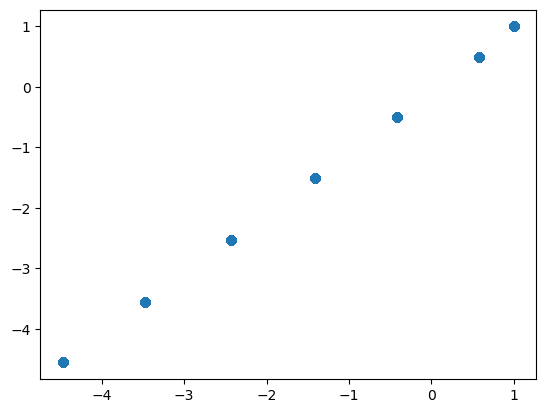

In [44]:
plt.scatter(np.log2(df_mxf_log["MXF_midpoint"]), df_mxf_log["MXF_midpoint_log"])

In [45]:
df_mxf_log.query("MXF_midpoint==2")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,MXF,...,MXF_upper_bound,MXF_quality,Path,Lineage,Binary,Primary_Lineage,category,MXF_lower_log,MXF_upper_log,MXF_midpoint_log
40,ERR4810929,ERS5300647,site.02.subj.0053.lab.22A003.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,>2.0,...,10000.0,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,2.2.1,1,2,original_test_set,1.0,13.287712,1.0
42,ERR4810950,ERS5300668,site.02.subj.0055.lab.22A005.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,>2.0,...,10000.0,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,2.2.1,1,2,original_train_set,1.0,13.287712,1.0
44,ERR4810970,ERS5300688,site.02.subj.0057.lab.22A007.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,>2.0,...,10000.0,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,2.2.1,1,2,original_test_set,1.0,13.287712,1.0
45,ERR4810981,ERS5300699,site.02.subj.0058.lab.22A008.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,>2.0,...,10000.0,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,2.2.1,1,2,original_train_set,1.0,13.287712,1.0
47,ERR4810467,ERS5298494,site.02.subj.0061.lab.22A011.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,>2.0,...,10000.0,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,2.2.1,1,2,original_train_set,1.0,13.287712,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6198,ERR4830564,ERS5319637,site.17.subj.P0082.lab.086-15-0082-B.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,>2.0,...,10000.0,MEDIUM,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,2.2.2,1,2,original_train_set,1.0,13.287712,1.0
6200,ERR4830558,ERS5319631,site.17.subj.P0150.lab.086-15-0150-B.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,>2.0,...,10000.0,MEDIUM,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,4.3.3,1,4,original_train_set,1.0,13.287712,1.0
6201,ERR4830559,ERS5319632,site.17.subj.P0150.lab.086-15-0150-M2.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,>2.0,...,10000.0,MEDIUM,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,4.3.3,1,4,original_train_set,1.0,13.287712,1.0
6206,ERR4830568,ERS5319641,site.17.subj.P3524.lab.086-15-3524-B.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,>2.0,...,10000.0,MEDIUM,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,2.2.2,1,2,original_train_set,1.0,13.287712,1.0


In [30]:
df_mxf["MXF_lower_log"] = np.log2(df_mxf[""])

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,MXF,MXF_lower_bound,MXF_midpoint,MXF_upper_bound,MXF_quality,Path,Lineage,Binary,Primary_Lineage,category
0,ERR4810493,ERS5298520,site.02.subj.0004.lab.2014222010.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.12,0.06,0.090,0.12,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,4.4.2,0,4,original_test_set
1,ERR4810494,ERS5298521,site.02.subj.0005.lab.2014222011.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.12,0.06,0.090,0.12,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,4.5,0,4,original_train_set
2,ERR4810495,ERS5298522,site.02.subj.0006.lab.2014222013.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.25,0.12,0.185,0.25,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,2.2.2,0,2,original_train_set
3,ERR4810497,ERS5298524,site.02.subj.0007.lab.2014222016.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.12,0.06,0.090,0.12,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,4.5,0,4,original_train_set
4,ERR4810498,ERS5298525,site.02.subj.0008.lab.2014222017.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.12,0.06,0.090,0.12,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,2.2.1,0,2,original_train_set
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6204,ERR4830552,ERS5319625,site.17.subj.P3038.lab.086-15-3038-B.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.25,0.12,0.185,0.25,MEDIUM,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,4.3.2.1,0,4,original_test_set
6205,ERR4830553,ERS5319626,site.17.subj.P3424.lab.086-15-3424-B.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.06,0.03,0.045,0.06,MEDIUM,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,4.3.3,0,4,original_train_set
6206,ERR4830568,ERS5319641,site.17.subj.P3524.lab.086-15-3524-B.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,>2.0,2.00,2.000,10000.00,MEDIUM,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,2.2.2,1,2,original_train_set
6207,ERR4830556,ERS5319629,site.17.subj.P3524.lab.086-15-3524-M2.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,>2.0,2.00,2.000,10000.00,MEDIUM,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,2.2.2,1,2,original_train_set


In [3]:
config_file = "config_moxi.yaml"
kwargs = yaml.safe_load(open(config_file, "r"))

drug = kwargs["drug"]
locus_list = kwargs["locus_list"]
filter_size = kwargs["filter_size"]
BATCH_SIZE = kwargs["batch_size"]
N_epochs = kwargs["N_epochs"]
patience_epochs = kwargs["patience_epochs"]

output_path = kwargs["output_path"]
phenotype_file = kwargs["phenotype_file"]
genotype_input_directory = kwargs["genotype_input_directory"]
binary_thresh = kwargs["binary_thresh"]
include_lineage = kwargs["include_lineage"]
loss_type = kwargs["loss_type"]
binary = False
bounded_loss = True

num_loci = len(locus_list)
df_phenos = pd.read_csv(phenotype_file)

if not os.path.isdir(output_path):
    os.mkdir(output_path)

if os.path.isfile(os.path.join(output_path, "pkl_sparse_train.npz")): 
    print("Input one-hot encodings file exists. Proceeding with modeling \n")    
else:
    print("Making input one-hot encodings file...\n")
    make_geno_pheno_files(**kwargs)
    
# get longest locus from the pickle file
X_h37rv = sparse.load_npz(os.path.join(output_path, 'pkl_sparse_ref.npz'))

# shape = 1 x 5 x longest_locus x num_loci
longest_locus = X_h37rv.shape[2]
del X_h37rv

val_generator = MtbGeneDataset(
    os.path.join(output_path, 'pkl_sparse_test.npz'),
    phenotype_file,
    drug,
    locus_list,
    train_or_test="original_test_set",
    binary=binary,
    cc=binary_thresh,
    include_lineage=include_lineage,
    bounded_loss=bounded_loss,
    data_idx=None,
    batch_size=BATCH_SIZE,
    shuffle=False
)        
        
if include_lineage:
    num_lineages = val_generator[0][0][1].shape[1]
else:
    num_lineages = 0


# need the train dataframe indices for slicing it. Reset index so that it's the index within the values, not in the overall dataframe
df_train = df_phenos.query("category=='original_train_set'").reset_index(drop=True)
df_test = df_phenos.query("category=='original_test_set'").reset_index(drop=True)

# initialize the model using the function from cnn_utils and the optimizer
model = conv_nn(binary, longest_locus, num_loci, num_lineages, bounded_loss, filter_size)
model.load_weights(os.path.join(output_path, "best_model.h5"))

Input one-hot encodings file exists. Proceeding with modeling 

1 loci, longest locus: 4832, 1465 isolates, 0 lineages
Fitting quantitative model


In [4]:
# get model predictions
y_pred = model.predict(x=val_generator,
                       workers=4,
                       use_multiprocessing=True,
)

# predictions dataframe: get indices of validation data in the cv splits
pred_df = df_test[["ROLLINGDB_ID", f"{drug}_midpoint", f"{drug}_lower_bound", f"{drug}_upper_bound"]]

12/12 [==============================] - 24s 2s/step


In [ ]:
for batch

In [7]:
val_generator[0].shape

AttributeError: 'tuple' object has no attribute 'shape'

In [8]:
val_generator[0][0].shape

AttributeError: 'list' object has no attribute 'shape'

In [9]:
len(val_generator[0])

2

In [10]:
len(val_generator[0][0])

3

In [19]:
drugs_lst = os.listdir("/n/data1/hms/dbmi/farhat/Sanjana/who-mutation-catalogue")
len(drugs_lst)

16

In [22]:
for drug in drugs_lst:
    
    if drug not in ["Rifampicin", "Isoniazid", "Ethambutol", "Pyrazinamide", "Streptomycin"]:
        
        if os.path.isdir(f"/n/data1/hms/dbmi/farhat/Sanjana/who-mutation-catalogue/{drug}/BINARY"):
            shutil.rmtree(f"/n/data1/hms/dbmi/farhat/Sanjana/who-mutation-catalogue/{drug}/BINARY")
        if os.path.isdir(f"/n/data1/hms/dbmi/farhat/Sanjana/who-mutation-catalogue/{drug}/MIC"):
            shutil.rmtree(f"/n/data1/hms/dbmi/farhat/Sanjana/who-mutation-catalogue/{drug}/MIC")

In [ ]:
"/Pretomanid/BINARY"

In [21]:
import shutil

In [15]:
mxf_lineages = get_lineages_matrix(df_mxf)

In [16]:
df_mxf.shape, mxf_lineages.shape

((7323, 19), (7323, 53))

In [10]:
rif_lineages = get_lineages_matrix(df_rif)

In [9]:
np.unique(mxf_lineages.sum(axis=1))

array([1, 2, 3, 4, 5])

In [11]:
np.unique(rif_lineages.sum(axis=1))

array([1, 2, 3, 4, 5])

In [13]:
mxf_lineages.shape, rif_lineages.shape

((7323, 53), (9349, 54))

In [14]:
mxf_lineages

,1,1.1.1,1.1.1.1,1.1.2,1.1.3,1.2.1,1.2.2,2,2.1,2.2.1,...,4.5,4.6,4.6.1.1,4.6.1.2,4.6.2,4.6.2.1,4.6.2.2,4.7,4.8,4.9
ERR4810493,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ERR4810494,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
ERR4810495,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
ERR4810497,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
ERR4810498,0,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SAMN02360611,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
SAMN02398715,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
SAMN01925692,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
SAMN02360569,0,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0


In [75]:
df_mxf

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,MXF,MXF_lower_bound,MXF_midpoint,MXF_upper_bound,MXF_quality,Path,Binary,Primary_Lineage,category,Lineage
0,ERR4810493,ERS5298520,site.02.subj.0004.lab.2014222010.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.12,0.06,0.090,0.12,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0,4,original_train_set,4.4.2
1,ERR4810494,ERS5298521,site.02.subj.0005.lab.2014222011.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.12,0.06,0.090,0.12,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0,4,original_train_set,4.5
2,ERR4810495,ERS5298522,site.02.subj.0006.lab.2014222013.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.25,0.12,0.185,0.25,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0,2,original_train_set,2.2.2
3,ERR4810497,ERS5298524,site.02.subj.0007.lab.2014222016.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.12,0.06,0.090,0.12,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0,4,original_train_set,4.5
4,ERR4810498,ERS5298525,site.02.subj.0008.lab.2014222017.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.12,0.06,0.090,0.12,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0,2,original_train_set,2.2.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7318,SAMN02360611,SAMN02360611,1400933.3,South Korea,PATRIC_20191206,"Lee Antimicrobial Agents and Chemotherapy, 2014",24100497.0,"Masan, Korea or Kampala, Uganda",m7h10,1-2,1.00,1.500,2.00,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,1,2,original_train_set,2.2.2
7319,SAMN02398715,SAMN02398715,1417030.3,South Korea,PATRIC_20191206,"Lee Antimicrobial Agents and Chemotherapy, 2014",24100497.0,"Masan, Korea or Kampala, Uganda",m7h10,>8,8.00,8.000,10000.00,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,1,2,original_test_set,2.2.2
7320,SAMN01925692,SAMN01925692,1295798.3,NaN,PATRIC_20191206,NaN,NaN,NaN,m7h10,>8,8.00,8.000,10000.00,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,1,4,original_train_set,4.5
7321,SAMN02360569,SAMN02360569,1400891.3,South Korea,PATRIC_20191206,"Lee Antimicrobial Agents and Chemotherapy, 2014",24100497.0,"Masan, Korea or Kampala, Uganda",m7h10,1-2,1.00,1.500,2.00,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,1,2,original_test_set,2.2.1


In [9]:
y.shape

(7323,)

In [10]:
lower_bound_log.shape, upper_bound_log.shape

((7323,), (7323,))

In [13]:
lower_bound_log

array([-4.05889369, -4.05889369, -3.05889369, ...,  3.        ,
        0.        ,  3.        ])

In [14]:
upper_bound_log

array([-3.05889369, -3.05889369, -2.        , ..., 13.28771238,
        1.        , 13.28771238])

In [59]:
y = []
drug = "RIF"
df_phenos = df_rif.copy()

for _, row in df_phenos.iterrows():

    # the upper bounds for the highest MICs have been changed to be a very large number, so doesn't make sense to 
    # take the midpoint of the lower and upper bounds. So log-transform the lower bound
    if ">" in row[drug]:
        y.append(np.log2(row[f"{drug}_lower_bound"]))
    # can't log-transform the lower bound of the lowest MICs (which is 0), so log-transform the upper bound
    elif "<=" in row[drug] or "<" in row[drug]:
        y.append(np.log2(row[f"{drug}_upper_bound"]))
    else:
        y.append(np.mean([np.log2(row[f"{drug}_lower_bound"]), np.log2(row[f"{drug}_upper_bound"])]))

    # the loss functions will not penalize predictions below the lowest MICs (unless the predicted MIC is negative) or above the highest MICs

y = np.array(y)

In [60]:
y_old = np.log2(df_phenos[f"{drug}_midpoint"])

In [68]:
np.inf in np.array([np.inf, 1, 2, 3])

True

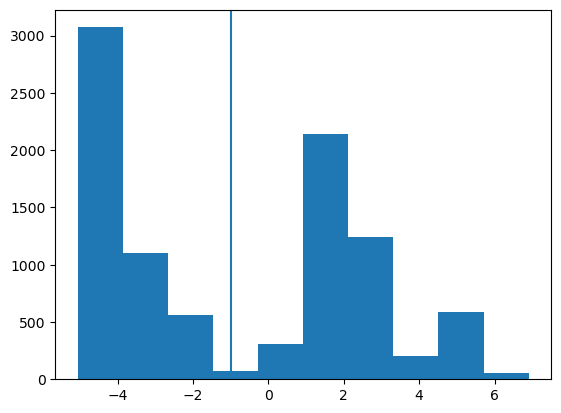

In [62]:
plt.hist(y)
plt.axvline(np.log2(0.5))

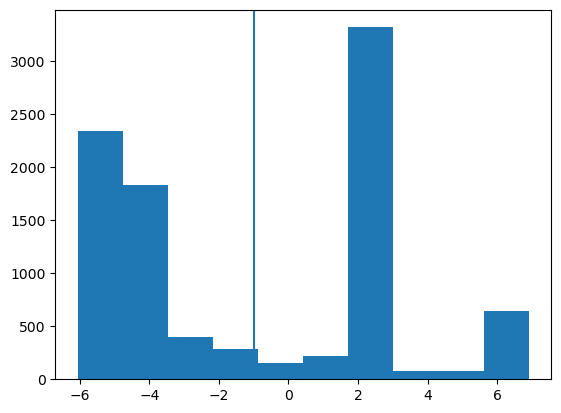

In [63]:
plt.hist(y_old)
plt.axvline(np.log2(0.5))

In [54]:
2**(-4)

0.0625

In [13]:
df_mxf.groupby("category")["MXF_midpoint"].mean()

category
original_test_set     0.424118
original_train_set    0.427450
Name: MXF_midpoint, dtype: float64

In [17]:
df_genos = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA/df_genos.csv")

In [20]:
df_mxf.shape, df_rif.shape

((7323, 19), (9349, 19))

In [18]:
df_genos

,ROLLINGDB_ID,gyrBA,category
0,ERR4810493,CACGTCGATCGGCCCAGAACAAGGCGCTCCGGTCCCGGCCTGAGAG...,original_train_set
1,ERR4810494,CACGTCGATCGGCCCAGAACAAGGCGCTCCGGTCCCGGCCTGAGAG...,original_train_set
2,ERR4810495,CACGTCGATCGGCCCAGAACAAGGCGCTCCGGTCCCGGCCTGAGAG...,original_train_set
3,ERR4810497,CACGTCGATCGGCCCAGAACAAGGCGCTCCGGTCCCGGCCTGAGAG...,original_train_set
4,ERR4810498,CACGTCGATCGGCCCAGAACAAGGCGCTCCGGTCCCGGCCTGAGAG...,original_train_set
...,...,...,...
7319,SAMN02398715,CACGTCGATCGGCCCAGAACAAGGCGCTCCGGTCCCGGCCTGAGAG...,original_test_set
7320,SAMN01925692,CACGTCGATCGGCCCAGAACAAGGCGCTCCGGTCCCGGCCTGAGAG...,original_train_set
7321,SAMN02360569,CACGTCGATCGGCCCAGAACAAGGCGCTCCGGTCCCGGCCTGAGAG...,original_test_set
7322,SAMN02364077,CACGTCGATCGGCCCAGAACAAGGCGCTCCGGTCCCGGCCTGAGAG...,original_train_set


In [14]:
gyrBA[:10]

[('ERR4810493.eff',
  Seq('CACGTCGATCGGCCCAGAACAAGGCGCTCCGGTCCCGGCCTGAGAGCCTCGAGG...TAA')),
 ('ERR4810494.eff',
  Seq('CACGTCGATCGGCCCAGAACAAGGCGCTCCGGTCCCGGCCTGAGAGCCTCGAGG...TAA')),
 ('ERR4810495.eff',
  Seq('CACGTCGATCGGCCCAGAACAAGGCGCTCCGGTCCCGGCCTGAGAGCCTCGAGG...TAA')),
 ('ERR4810497.eff',
  Seq('CACGTCGATCGGCCCAGAACAAGGCGCTCCGGTCCCGGCCTGAGAGCCTCGAGG...TAA')),
 ('ERR4810498.eff',
  Seq('CACGTCGATCGGCCCAGAACAAGGCGCTCCGGTCCCGGCCTGAGAGCCTCGAGG...TAA')),
 ('ERR4810507.eff',
  Seq('CACGTCGATCGGCCCAGAACAAGGCGCTCCGGTCCCGGCCTGAGAGCCTCGAGG...TAA')),
 ('ERR4810512.eff',
  Seq('CACGTCGATCGGCCCAGAACAAGGCGCTCCGGTCCCGGCCTGAGAGCCTCGAGG...TAA')),
 ('ERR4810516.eff',
  Seq('CACGTCGATCGGCCCAGAACAAGGCGCTCCGGTCCCGGCCTGAGAGCCTCGAGG...TAA')),
 ('ERR4810518.eff',
  Seq('CACGTCGATCGGCCCAGAACAAGGCGCTCCGGTCCCGGCCTGAGAGCCTCGAGG...TAA')),
 ('ERR4810520.eff',
  Seq('CACGTCGATCGGCCCAGAACAAGGCGCTCCGGTCCCGGCCTGAGAGCCTCGAGG...TAA'))]

In [7]:
gyrBA = [(seq.id, seq.seq) for seq in SeqIO.parse("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/fastas/gyrBA.fasta", "fasta")]

lengths = [len(seq[1]) for seq in gyrBA]
np.unique(lengths)

array([4832])

In [8]:
rpoBC = [(seq.id, seq.seq) for seq in SeqIO.parse("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/fastas/rpoBC.fasta", "fasta")]

lengths = [len(seq[1]) for seq in rpoBC]
np.unique(lengths)

array([7826])

In [9]:
rpoBC[0][1]

Seq('GCCCACCTCACCCGCCACTTGACACCGT-GGTCTTAGTC---------------...TAG')

In [4]:
gyrBA[0]

('ERR4810493.eff',
 Seq('CACGTCGATCGGCCCAGAACAAGGCGCTCCGGTCCCGGCCTGAGAGCCTCGAGG...TAA'))

In [ ]:
gyrBA[0]

In [2]:
df_mxf["Path"].values[0]

'/n/data1/hms/dbmi/farhat/rollingDB/cryptic_output/ERR4810493/pilon/ERR4810493_full.vcf.gz'

In [48]:
"/n/scratch3/users/s/sak0914/annotated_VCF/Peru4994.eff.vcf" in mxf_paths[0].values

True

In [49]:
"/n/scratch3/users/s/sak0914/annotated_VCF/Peru4994.eff.vcf" in rif_paths[0].values

True

In [51]:
mxf_paths = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/combined_paths_for_aln.txt", sep="\t", header=None)

for fName in mxf_paths[0].values:
    if not os.path.isfile(fName):
        print(f"{fName} is not a file")
        
for fName in mxf_paths[0].values:
    with open(fName, "r") as file:
        if len(file.readlines()) < 100:
            print(f"{fName} is sus")

In [52]:
rif_paths = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/combined_paths_for_aln.txt", sep="\t", header=None)

for fName in rif_paths[0].values:
    if not os.path.isfile(fName):
        print(f"{fName} is not a file")
        
for fName in rif_paths[0].values:
    with open(fName, "r") as file:
        if len(file.readlines()) < 100:
            print(f"{fName} is sus")

In [ ]:
python3 data_processing/06_make_MSA.py /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/combined_paths_for_aln.txt 4997 9818 POS /n/data1/hms/dbmi/farhat/Sanjana/CNN_results/fastas/gyrBA.fasta



In [ ]:
python3 data_processing/06_make_MSA.py /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/combined_paths_for_aln.txt 759610 767320 POS /n/data1/hms/dbmi/farhat/Sanjana/CNN_results/fastas/rpoBC.fasta


In [36]:
df_rif.query("ROLLINGDB_ID=='Peru4994'")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,RIF,RIF_lower_bound,RIF_midpoint,RIF_upper_bound,RIF_quality,Path,Lineage,Binary,Primary_Lineage,category
8851,Peru4994,SAMN05916315,Peru4994,Peru,farhat_internal,NaN,NaN,NJH,m7h10,>50,50.0,50.0,50000.0,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,4.9,1,4,original_train_set


In [37]:
df_mxf.query("ROLLINGDB_ID=='Peru4994'")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,MXF,MXF_lower_bound,MXF_midpoint,MXF_upper_bound,MXF_quality,Path,Lineage,Binary,Primary_Lineage,category
7051,Peru4994,SAMN05916315,Peru4994,Peru,farhat_internal,NaN,NaN,NJH,m7h10,0.5-1,0.5,0.75,1.0,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,4.9,1,4,original_train_set


In [38]:
who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_resistance_variants_all.csv")


In [ ]:
file.readlines()

In [15]:
df_mxf.query("ROLLINGDB_ID=='Peru4994'")["Path"].values[0]

'/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/Peru4994/pilon/Peru4994_full.vcf.gz'

In [ ]:
/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/Peru4994/pilon/Peru4994_full.vcf.gz

In [18]:
mxf_validation_data = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/validation_data_for_model.csv")

In [20]:
mxf_validation_data["FASTQ1_FILE"].values[0]

'/n/data1/hms/dbmi/farhat/rollingDB/fastq_db/JPN-R2012-0001/JPN-R2012-0001_R1.fastq.gz'

In [ ]:
/n/data1/hms/dbmi/farhat/rollingDB/fastq_db/Peru4994

In [23]:
pd.DataFrame({"ROLLINGDB_ID": "Peru4994", 
              "FASTQ1_FILE": "/n/data1/hms/dbmi/farhat/rollingDB/fastq_db/Peru4994/Peru4994_R1.fastq.gz",
              "FASTQ2_FILE": "/n/data1/hms/dbmi/farhat/rollingDB/fastq_db/Peru4994/Peru4994_R2.fastq.gz"
             }, index=[0]).to_csv("megapipe_debug.tsv", sep="\t", index=False, header=None)

In [ ]:
bcftools filter -i "POS >= 759611 & POS <= 767320" /n/scratch3/users/s/sak0914/annotated_VCF/ERR4828928.eff.vcf
bcftools filter -i "POS >= 759611 & POS <= 767320" /n/scratch3/users/s/sak0914/annotated_VCF/ERR4831025.eff.vcf

In [196]:
MXF_PASS_prop.query("PASS_prop < 0.75")

,ROLLINGDB_ID,PASS_prop
844,ERR4822323,0.5


In [ ]:
bcftools filter -i "POS >= 4998 & POS <= 9818" /n/scratch3/users/s/sak0914/annotated_VCF/ERR4822323.eff.vcf

In [4]:
# paths_df = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/MIC_ML_data.csv")
validation_data = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/MIC/MIC_ML_consortium_MIC_table.csv").rename(columns={"MOXI_lower_bound": "MXF_lower_bound",
                                                                                                                              "MOXI_midpoint": "MXF_midpoint",
                                                                                                                              "MOXI_upper_bound": "MXF_upper_bound",
                                                                                                                              "MOXI_quality": "MXF_quality"
                                                                                                                             })

validation_data_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv")

validation_data.shape, validation_data_metadata.shape

((2212, 74), (19631, 7))

In [5]:
paths_df = pd.DataFrame(columns=["ROLLINGDB_ID", "FASTQ1_FILE", "FASTQ2_FILE"] + list(validation_data.columns[~validation_data.columns.isin(["ID", "BIOSAMPLE_ACCESSION", "ROLLINGDB_ID"])])).set_index("ROLLINGDB_ID")

for _, row in validation_data.iterrows():

    possible_dirs = [row["ID"], row["BIOSAMPLE_ACCESSION"], row["ROLLINGDB_ID"]]
    found_dir = False

    for dir_name in possible_dirs:
        if not pd.isnull(dir_name):
            sample_dir = f"/n/data1/hms/dbmi/farhat/rollingDB/fastq_db/{dir_name}"

            if os.path.isdir(sample_dir):
                sample_id = os.path.basename(sample_dir)
                found_dir = True
                break

    if found_dir:
        reads_1 = f"{sample_dir}/{dir_name}_R1.fastq.gz"
        reads_2 = f"{sample_dir}/{dir_name}_R2.fastq.gz"

        if not os.path.isfile(reads_1) or not os.path.isfile(reads_2):
            #print(f"{sample_dir} does not contain both reads files!")
            if validation_data_metadata.query("ROLLINGDB_ID == @sample_id")["UNPAIRED/PAIRED"].values[0] == 0:
                print(f"{sample_dir} contains unpaired data!")
        else:            
            # add the remaining columns to the dataframe as well
            add_data = pd.DataFrame(row).T
            add_data = add_data[add_data.columns[~add_data.columns.isin(["ID", "BIOSAMPLE_ACCESSION", "ROLLINGDB_ID"])]]

            paths_df.loc[dir_name, :] = [reads_1, reads_2] + list(np.squeeze(add_data.values))


paths_df = paths_df.reset_index()
print(paths_df.shape)

assert len(paths_df.ROLLINGDB_ID.unique()) == len(paths_df)

# # save full dataframe
# paths_df.rename(columns={"MOXI": "MXF"}, inplace=True)
# paths_df.to_csv(MIC_ML_data, index=False)

# # save the 3 columns for running the processing pipeline to get VCF files
# paths_df[["ROLLINGDB_ID", "FASTQ1_FILE", "FASTQ2_FILE"]].to_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/MIC_ML_metadata_for_megapipe.tsv", index=False, header=None, sep="\t")

/n/data1/hms/dbmi/farhat/rollingDB/fastq_db/20802 contains unpaired data!
/n/data1/hms/dbmi/farhat/rollingDB/fastq_db/23155 contains unpaired data!
/n/data1/hms/dbmi/farhat/rollingDB/fastq_db/31309 contains unpaired data!
(1769, 74)


In [34]:
keep_samples = paths_df.loc[(~pd.isnull(paths_df["RIF_midpoint"])) | (~pd.isnull(paths_df["MXF_midpoint"]))][["ROLLINGDB_ID", "FASTQ1_FILE", "FASTQ2_FILE", "RIF_quality", "RIF_lower_bound", "RIF_midpoint", "RIF_upper_bound", "MXF_quality", "MXF_lower_bound", "MXF_midpoint", "MXF_upper_bound"]]
print(keep_samples.shape)

(1480, 11)


In [33]:
out_dir = "/n/scratch3/users/s/sak0914/MIC_ML"

unclassified_thresh = 25
high_unclassified_prop = []
finished_samples = 0
unfinished_samples = []

# for each sample, get the distribution of classified (MTBC) vs. unclassified (not MTBC) reads
for sample_id in keep_samples["ROLLINGDB_ID"].values:
    
    #if os.path.isfile(os.path.join(out_dir, sample_id, "kraken/kraken_report")):
    if os.path.isfile(os.path.join(out_dir, sample_id, f"pilon/{sample_id}_full.vcf.gz")):
        
        if not os.path.isfile(os.path.join(out_dir, sample_id, f"pilon/{sample_id}.vcf")):
            print(f'{os.path.join(out_dir, sample_id, f"pilon/{sample_id}.vcf")}' is missing)

        # kraken_class = pd.read_csv(os.path.join(out_dir, sample_id, "kraken/kraken_classifications"), sep="\t", header=None)
        kraken_report = pd.read_csv(os.path.join(out_dir, sample_id, "kraken/kraken_report"), sep="\t", header=None)
        
        # this is out of 100
        if "unclassified" in kraken_report[5].values:
            unclassified_percent = kraken_report.loc[kraken_report[5]=="unclassified"][0].values[0]
        else:
            unclassified_percent = 0

        if unclassified_percent > unclassified_thresh:
            high_unclassified_prop.append([sample_id, unclassified_percent])
            
        finished_samples += 1
        
    else:
        unfinished_samples.append(sample_id)
        
print(f"Finished {finished_samples}/{len(keep_samples)} samples")
print(f"{len(high_unclassified_prop)}/{finished_samples} samples have more than {unclassified_thresh}% unclassified reads")

high_unclassified_samples, _ = list(zip(*high_unclassified_prop))

Finished 1480/1480 samples
21/1480 samples have more than 25% unclassified reads


In [24]:
# were printed to stdout if the max depth >= 10
finished_check_samples = pd.read_csv("/home/sak0914/Errors/zerrors_4705583.out", sep="\t", header=None)[0].values
len(finished_check_samples)

1313

In [32]:
# remainder that need to be checked
print(keep_samples.query("ROLLINGDB_ID not in @finished_check_samples").shape)
keep_samples.query("ROLLINGDB_ID not in @finished_check_samples")[["ROLLINGDB_ID"]].to_csv("samples.csv", index=False)

(167, 11)


In [6]:
# neede to be fixed (already done earlier!)
23194
KOR-K2016-0201

(1480, 11)


In [ ]:
C349
C381

In [35]:
keep_samples.query("ROLLINGDB_ID in ['C349', 'C381']")[["ROLLINGDB_ID", "FASTQ1_FILE", "FASTQ2_FILE"]].to_csv("megapipe_debug.tsv", sep="\t", header=None, index=False)

In [36]:
pd.read_csv("megapipe_debug.tsv", sep="\t", header=None)

,0,1,2
0,C349,/n/data1/hms/dbmi/farhat/rollingDB/fastq_db/C3...,/n/data1/hms/dbmi/farhat/rollingDB/fastq_db/C3...
1,C381,/n/data1/hms/dbmi/farhat/rollingDB/fastq_db/C3...,/n/data1/hms/dbmi/farhat/rollingDB/fastq_db/C3...


In [37]:
pd.read_csv("megapipe_debug.tsv", sep="\t", header=None)[1].values

array(['/n/data1/hms/dbmi/farhat/rollingDB/fastq_db/C349/C349_R1.fastq.gz',
       '/n/data1/hms/dbmi/farhat/rollingDB/fastq_db/C381/C381_R1.fastq.gz'],
      dtype=object)

In [17]:
# check if there are any remaining fastq files that can be deleted
count = 0
for sample_id in os.listdir(out_dir):
    
    if os.path.isfile(os.path.join(out_dir, sample_id, "pilon", f"{sample_id}.vcf")):
        
        if len(os.listdir(os.path.join(out_dir, sample_id))) > 3:
            print(os.listdir(os.path.join(out_dir, sample_id)))

In [107]:
df_mxf_validation = paths_df.loc[~pd.isnull(paths_df["MXF_midpoint"]) & ~paths_df["ROLLINGDB_ID"].isin(high_unclassified_samples)][['ROLLINGDB_ID', 'FASTQ1_FILE', 'FASTQ2_FILE', 'ISOLATION_LOCATION',
                                                                                                                    'DB_OF_ORIGIN', 'STUDY_NAME', 'STUDY_PMID', 'TESTING_LOCATION', 'MEDIA', 'MXF_midpoint']]

df_mxf_validation.shape

(1323, 10)

In [109]:
df_rif_validation = paths_df.loc[~pd.isnull(paths_df["RIF_midpoint"]) & ~paths_df["ROLLINGDB_ID"].isin(high_unclassified_samples)][['ROLLINGDB_ID', 'FASTQ1_FILE', 'FASTQ2_FILE', 'ISOLATION_LOCATION',
                                                                                                                    'DB_OF_ORIGIN', 'STUDY_NAME', 'STUDY_PMID', 'TESTING_LOCATION', 'MEDIA', 'RIF_midpoint']]

df_rif_validation.shape


(1460, 10)

In [24]:
group_size = 275
num_groups = int(np.ceil(len(paths_df)/group_size))

for i in range(num_groups):
    paths_df[["ROLLINGDB_ID", "FASTQ1_FILE", "FASTQ2_FILE"]].iloc[i*group_size:(i+1)*group_size, :].to_csv(f"megapipe_{i+1}.tsv", index=False, header=None, sep="\t")
    
# paths_df.iloc[271:271*2, :].to_csv("RIF_MXF_megapipe_2.tsv", index=False, header=None, sep="\t")
# paths_df.iloc[271*2:271*3, :].to_csv("RIF_MXF_megapipe_3.tsv", index=False, header=None, sep="\t")
# paths_df.iloc[271*3:, :].to_csv("RIF_MXF_megapipe_4.tsv", index=False, header=None, sep="\t")

In [128]:
df_mxf["Path"].values[0]

'/n/data1/hms/dbmi/farhat/rollingDB/cryptic_output/ERR4810493/pilon/ERR4810493_full.vcf.gz'

In [135]:
def get_proportion_PASSed(sample_id, START, END, vcf_dir="/n/scratch3/users/s/sak0914/annotated_VCF"):
    
    fName = f"{vcf_dir}/{sample_id}.eff.vcf"
    
    if not os.path.isfile(fName):
        print(f"{fName} doesn't exist!")
    else:
        
        num_var = 0
        num_PASS = 0
        
        vcf_reader = vcf.Reader(filename=fName)
        
        for record in vcf_reader:
            if record.POS >= START and record.POS <= END:
                num_var += 1
                
                if len(record.FILTER) == 0:
                    num_PASS += 1
                    
        return num_PASS / num_var

In [139]:
vcf_dir="/n/scratch3/users/s/sak0914/annotated_VCF"
sample_id = "ERR4810493"

In [140]:
f"{vcf_dir}/{sample_id}.eff.vcf"

'/n/scratch3/users/s/sak0914/annotated_VCF/ERR4810493.eff.vcf'

In [ ]:
# get all variants and exclude header lines
num_pass = $(bcftools filter -i "POS >= 4998 & POS <= 9818 & FILTER == 'PASS'" /n/scratch3/users/s/sak0914/annotated_VCF/ERR4810493.eff.vcf | awk '$1 !~ /^#/' | wc -l)
num_var = $(bcftools filter -i "POS >= 4998 & POS <= 9818" /n/scratch3/users/s/sak0914/annotated_VCF/ERR4810493.eff.vcf | awk '$1 !~ /^#/' | wc -l)



In [ ]:
bcftools filter -i`b "POS >= 4998 & POS <= 9818 & FILTER == 'PASS'" /n/scratch3/users/s/sak0914/annotated_VCF/ERR4810493.eff.vcf | awk '$1 !~ /^#/' | wc -l

In [ ]:
data_processing/QC_scripts/check_pass_proportion.sh /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/data_for_model.csv MXF_low_PASS_samples.csv /n/scratch3/users/s/sak0914/annotated_VCF 4998 9818



In [ ]:
input_file=$1
output_file=$2
vcf_dir=$3
START=$4
END=$5

In [137]:
for i, sample_id in enumerate(df_mxf["ROLLINGDB_ID"].values):
    if get_proportion_PASSed(sample_id, 4998, 9818) < 0.75:
        print(sample_id)
    print(i)

0
1
2
3
4
5
6
7
8



KeyboardInterrupt

